**Environment setup**

In [1]:
from google.colab import drive
import numpy as np
from copy import deepcopy
import pandas as pd

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Necessary parameter setup**

In [3]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [4]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [5]:
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/Plot_Utility.py'
with open(utility_link) as f: exec(f.read())

**Rosenbrock Example**

In [6]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Rosen_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Rosen_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# New PF initialization:
# MSE vs Warmups:
pf_MSE_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/Rosen_MSE.pkl"
pf_MSE_c_df = pd.read_pickle(pf_MSE_c_path)
# MSE vs nested Rhat:
pf_R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/Rosen_R_Hat.pkl"
pf_R_Hat_c_df = pd.read_pickle(pf_R_Hat_c_path)

# MSE vs Warmups:
pf_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Rosen_MSE.pkl"
pf_MSE_n_df = pd.read_pickle(pf_MSE_n_path)
# MSE vs nested Rhat:
pf_R_Hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Rosen_R_Hat.pkl"
pf_R_Hat_n_df = pd.read_pickle(pf_R_Hat_n_path)
print("PathFinder implementation data Loaded!")

TFP implementation data Loaded!
BlackJAX implementation data Loaded!
PathFinder implementation data Loaded!


*Original Paper: line plot*

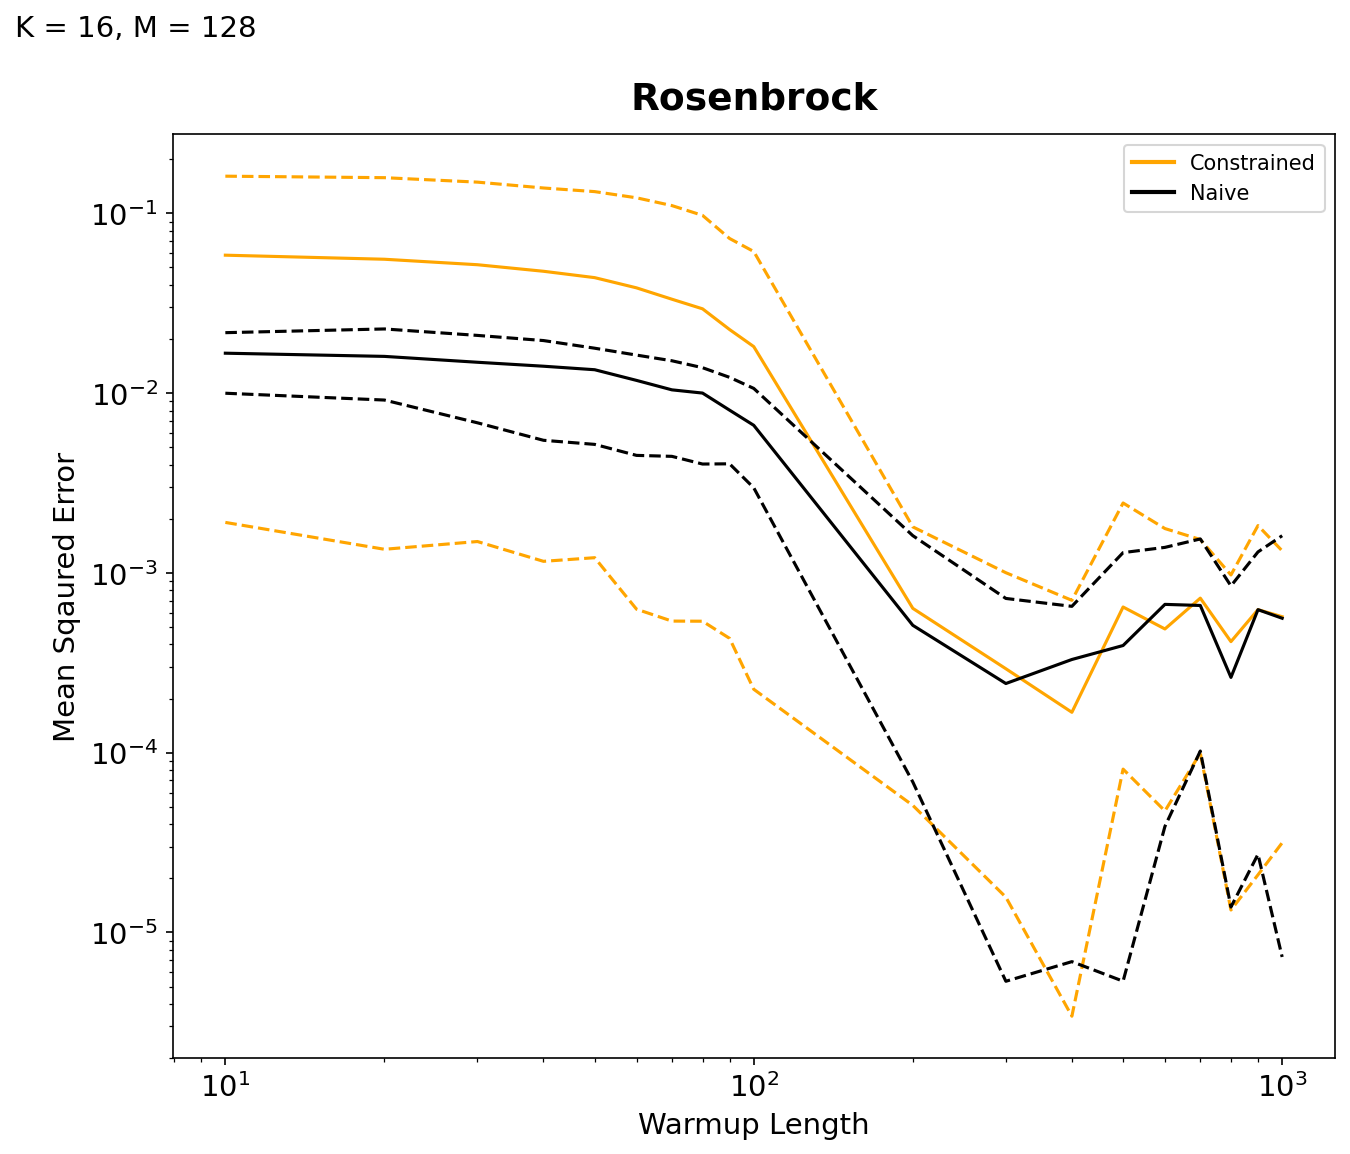

In [7]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Rosenbrock", num_super_chains,M)

*Original Paper: Scatter plot*

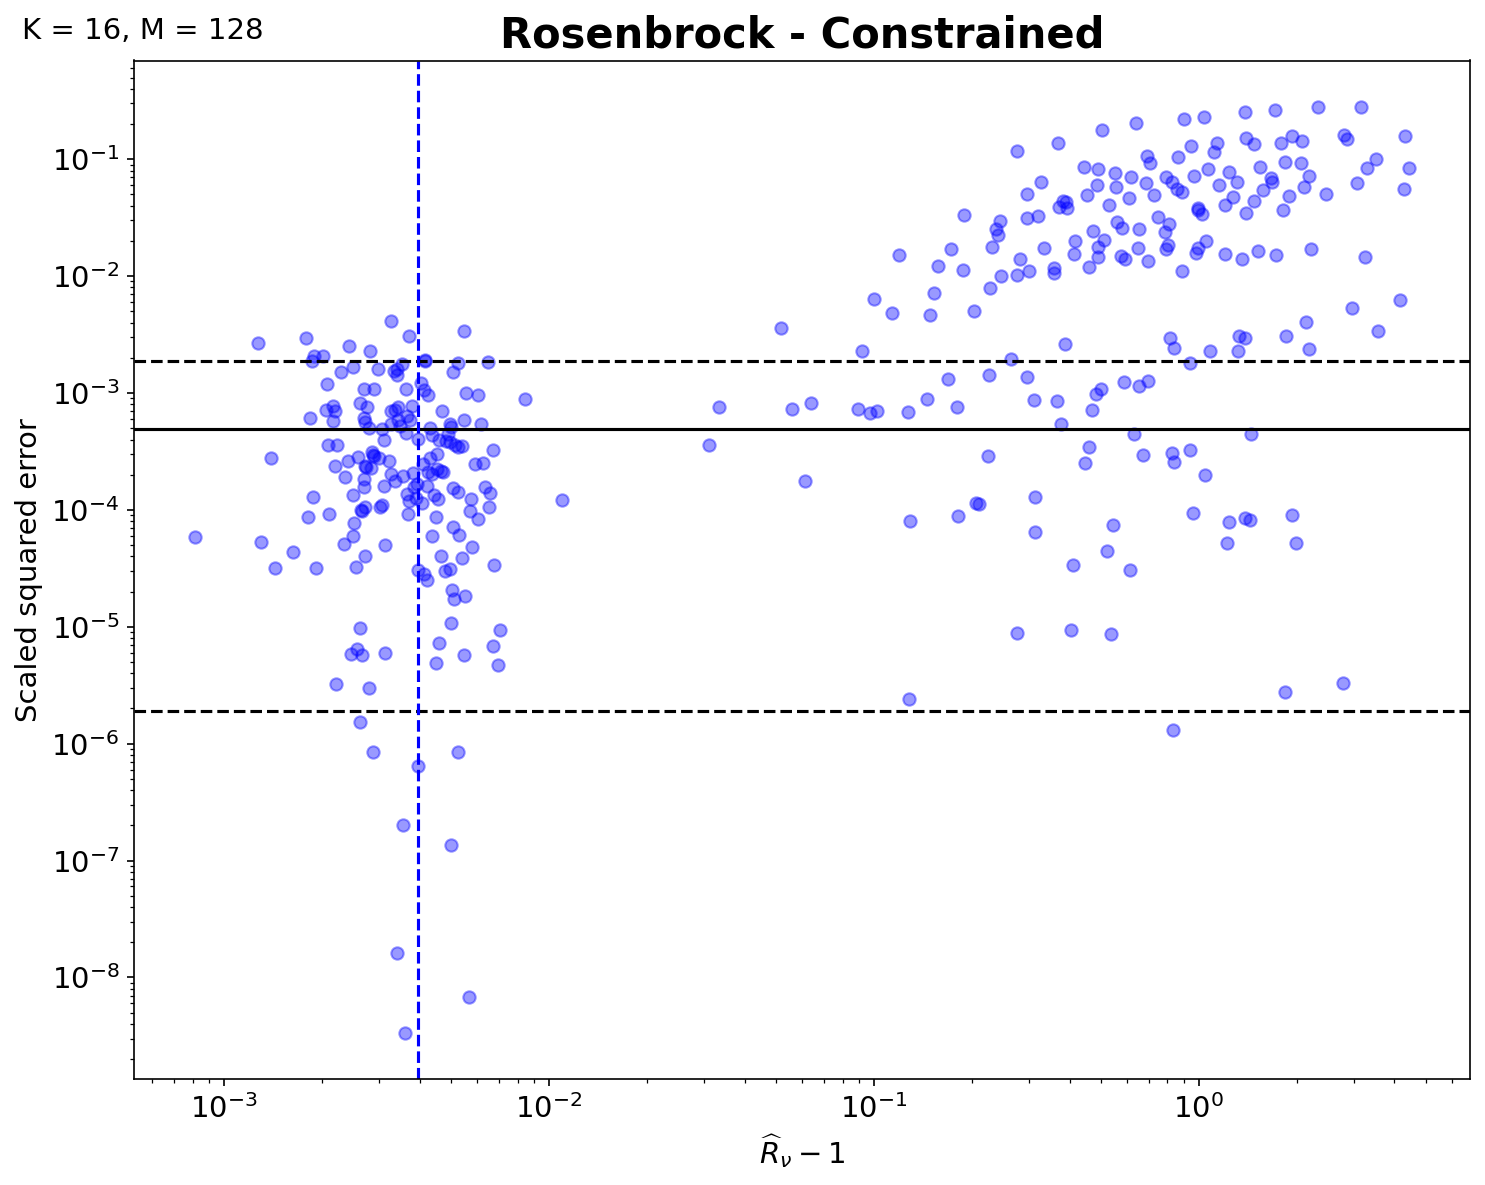

In [8]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Rosenbrock", False,
            bound, threshold,num_super_chains,num_chains_short)

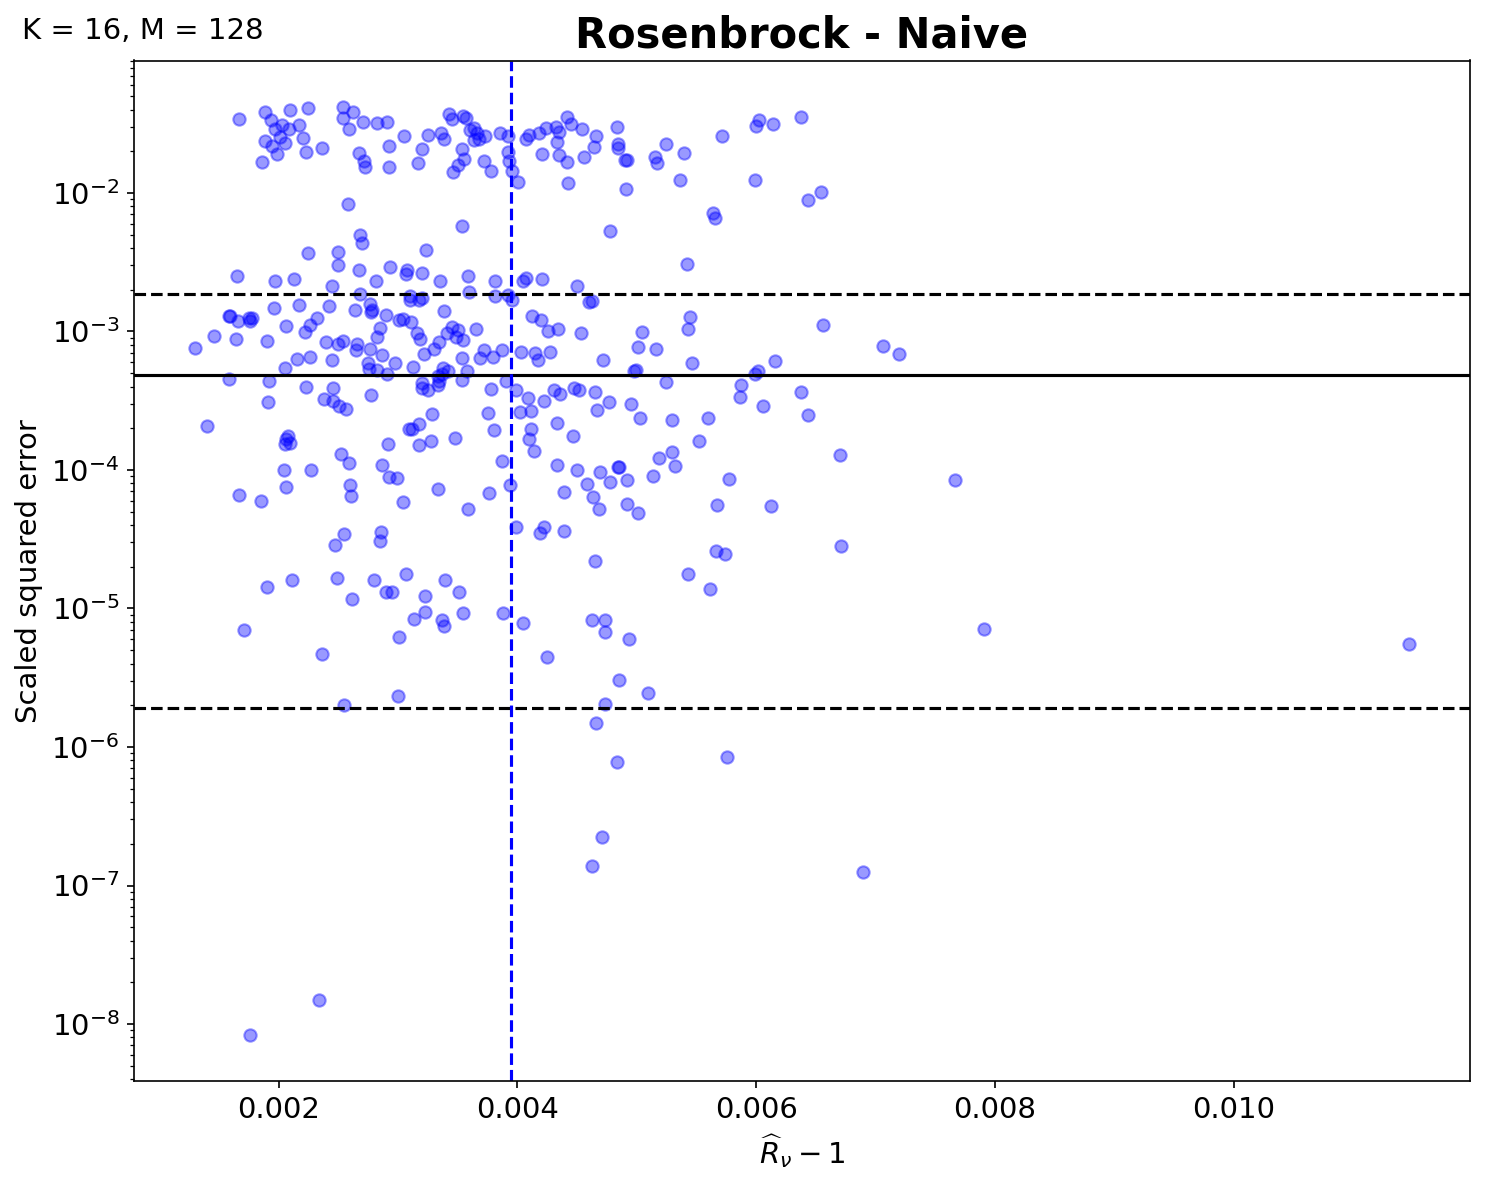

In [9]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Rosenbrock", True,
            bound, threshold,num_super_chains, num_chains_short)

*Enhanced Plots: multiple line plots*

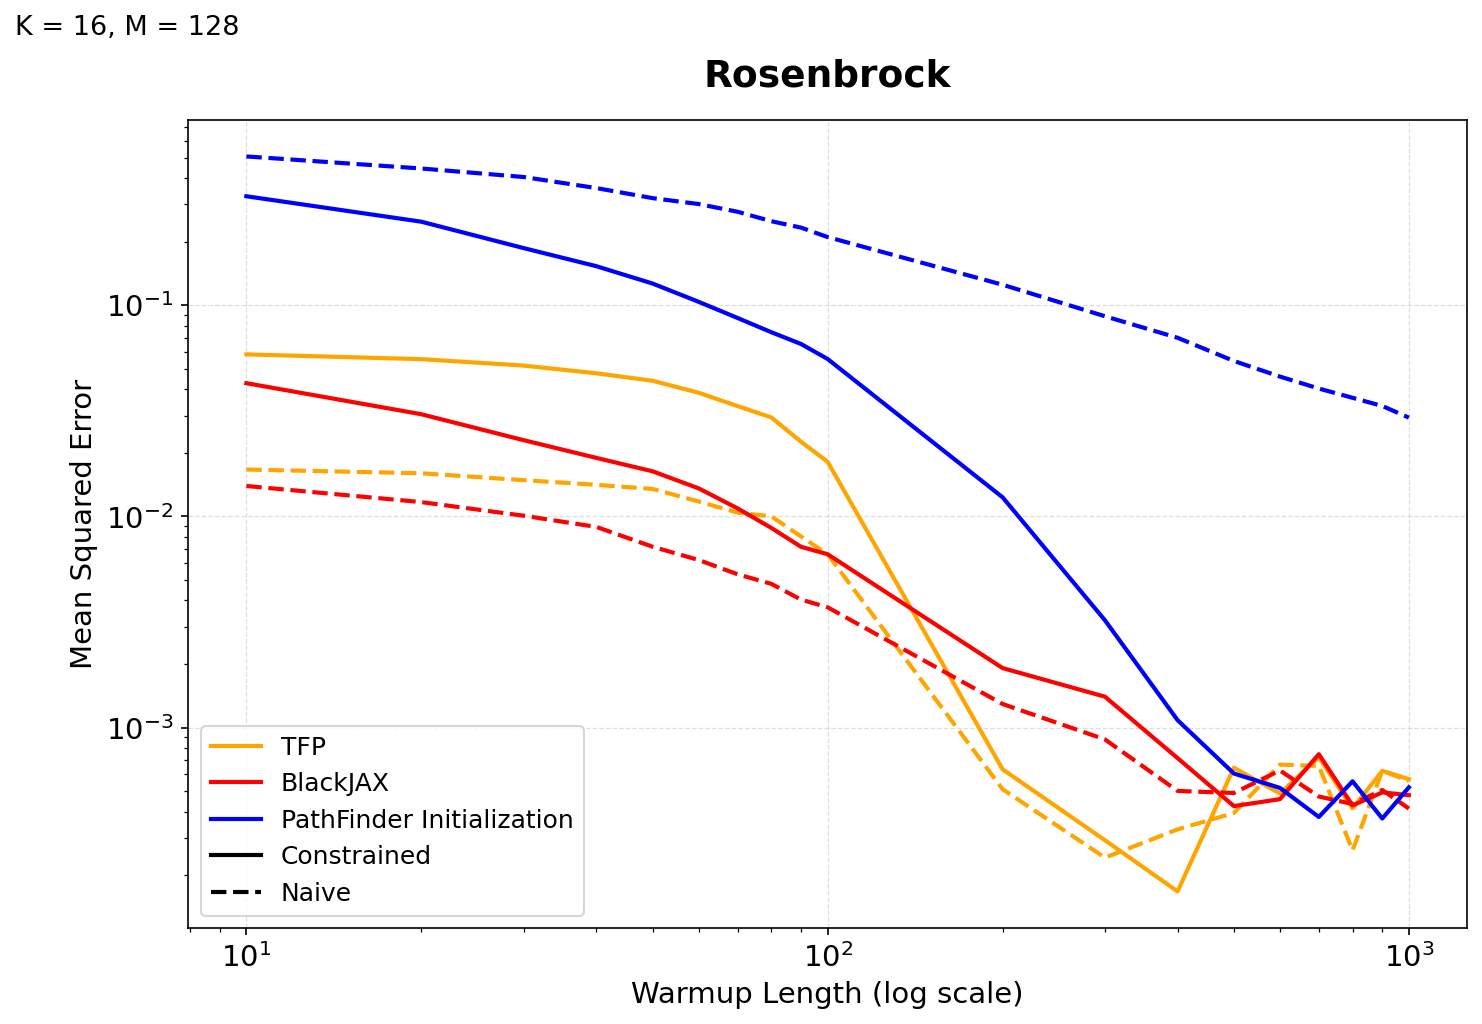

In [10]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_c_df, pf_MSE_n_df,
                    "Rosenbrock", num_super_chains,M)

*Enhanced Plots: colored Scatter Plots*

In [11]:
dfs=[tfp_R_Hat_c_df, bjx_R_Hat_c_df, pf_R_Hat_c_df,
     tfp_R_Hat_n_df, bjx_R_Hat_n_df, pf_R_Hat_n_df]
titles =["TFP - Constrained","BlackJAX - Constrained","PathFinder - Constrained",
         "TFP - Naive","BlackJAX - Naive","PathFinder - Naive"]

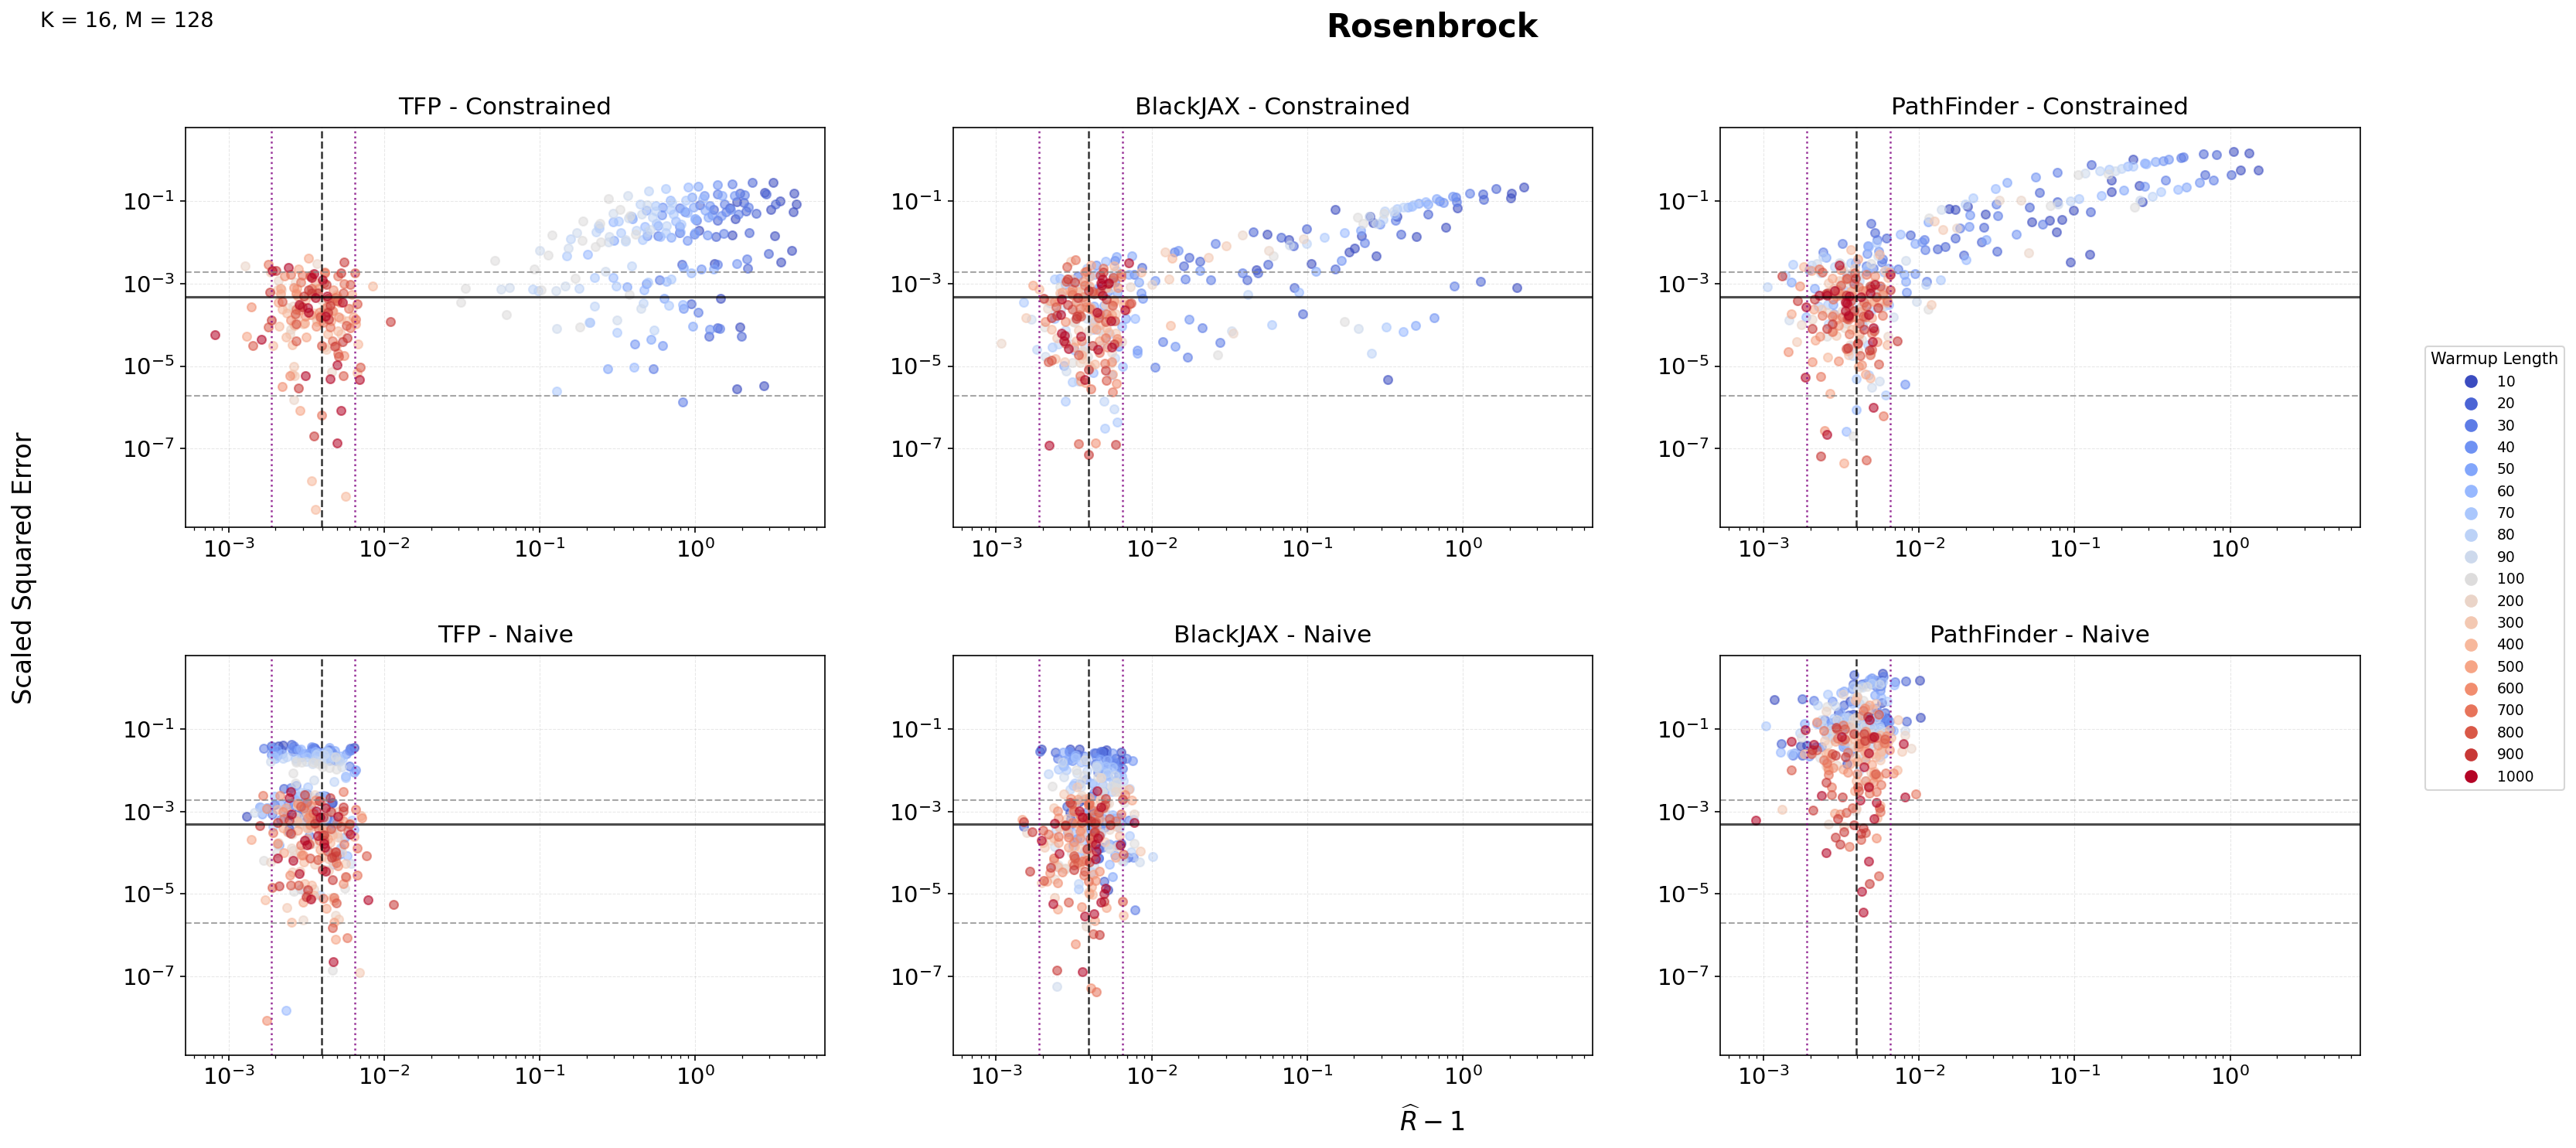

In [12]:
MSE_vs_Rhat_color(dfs, titles,"Rosenbrock",bound,
                  threshold, num_chains_short, num_super_chains)

**Bimodal Example**

In [13]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/Bimodal_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/Bim_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# New PF initialization:
# MSE vs Warmups:
pf_MSE_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/Bim_MSE.pkl"
pf_MSE_c_df = pd.read_pickle(pf_MSE_c_path)
# MSE vs nested Rhat:
pf_R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/Bim_R_Hat.pkl"
pf_R_Hat_c_df = pd.read_pickle(pf_R_Hat_c_path)

# MSE vs Warmups:
pf_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Bim_MSE.pkl"
pf_MSE_n_df = pd.read_pickle(pf_MSE_n_path)
# MSE vs nested Rhat:
pf_R_Hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/Bim_R_Hat.pkl"
pf_R_Hat_n_df = pd.read_pickle(pf_R_Hat_n_path)
print("PathFinder implementation data Loaded!")

TFP implementation data Loaded!
BlackJAX implementation data Loaded!
PathFinder implementation data Loaded!


*Original Paper: Line Plot*

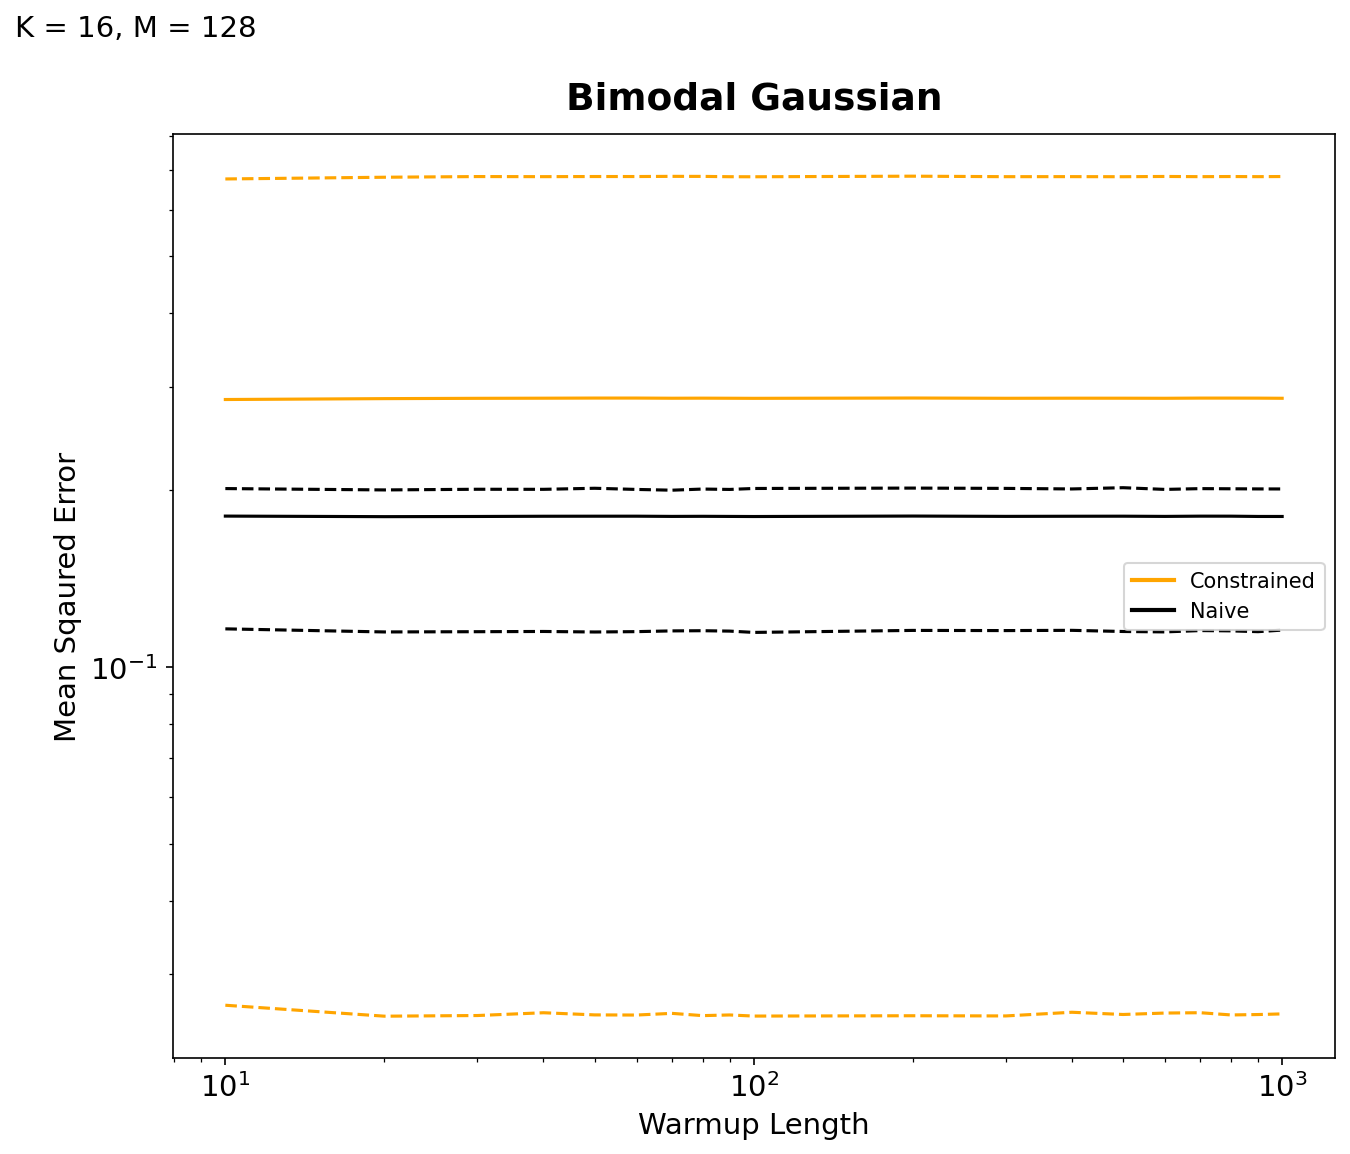

In [14]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Bimodal Gaussian", num_super_chains, M)

*Original Paper: Scatter plot*

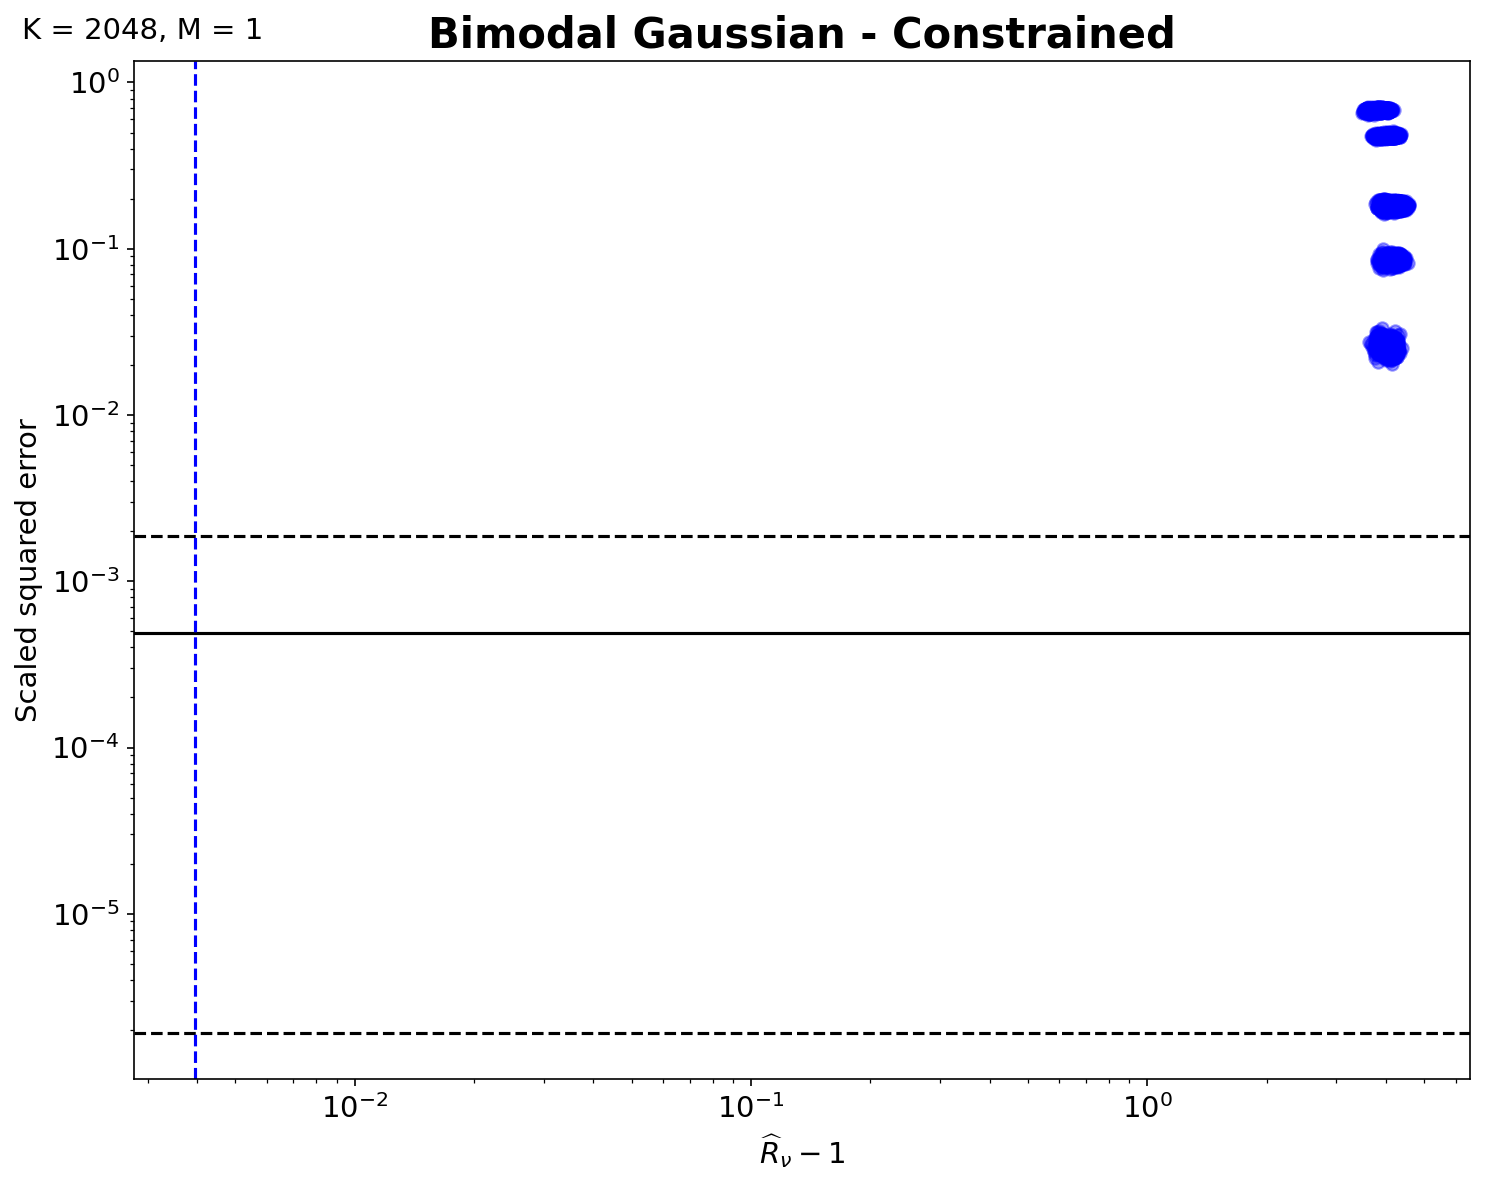

In [15]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Bimodal Gaussian", False,
            bound, threshold,num_chains_short, num_chains_short)

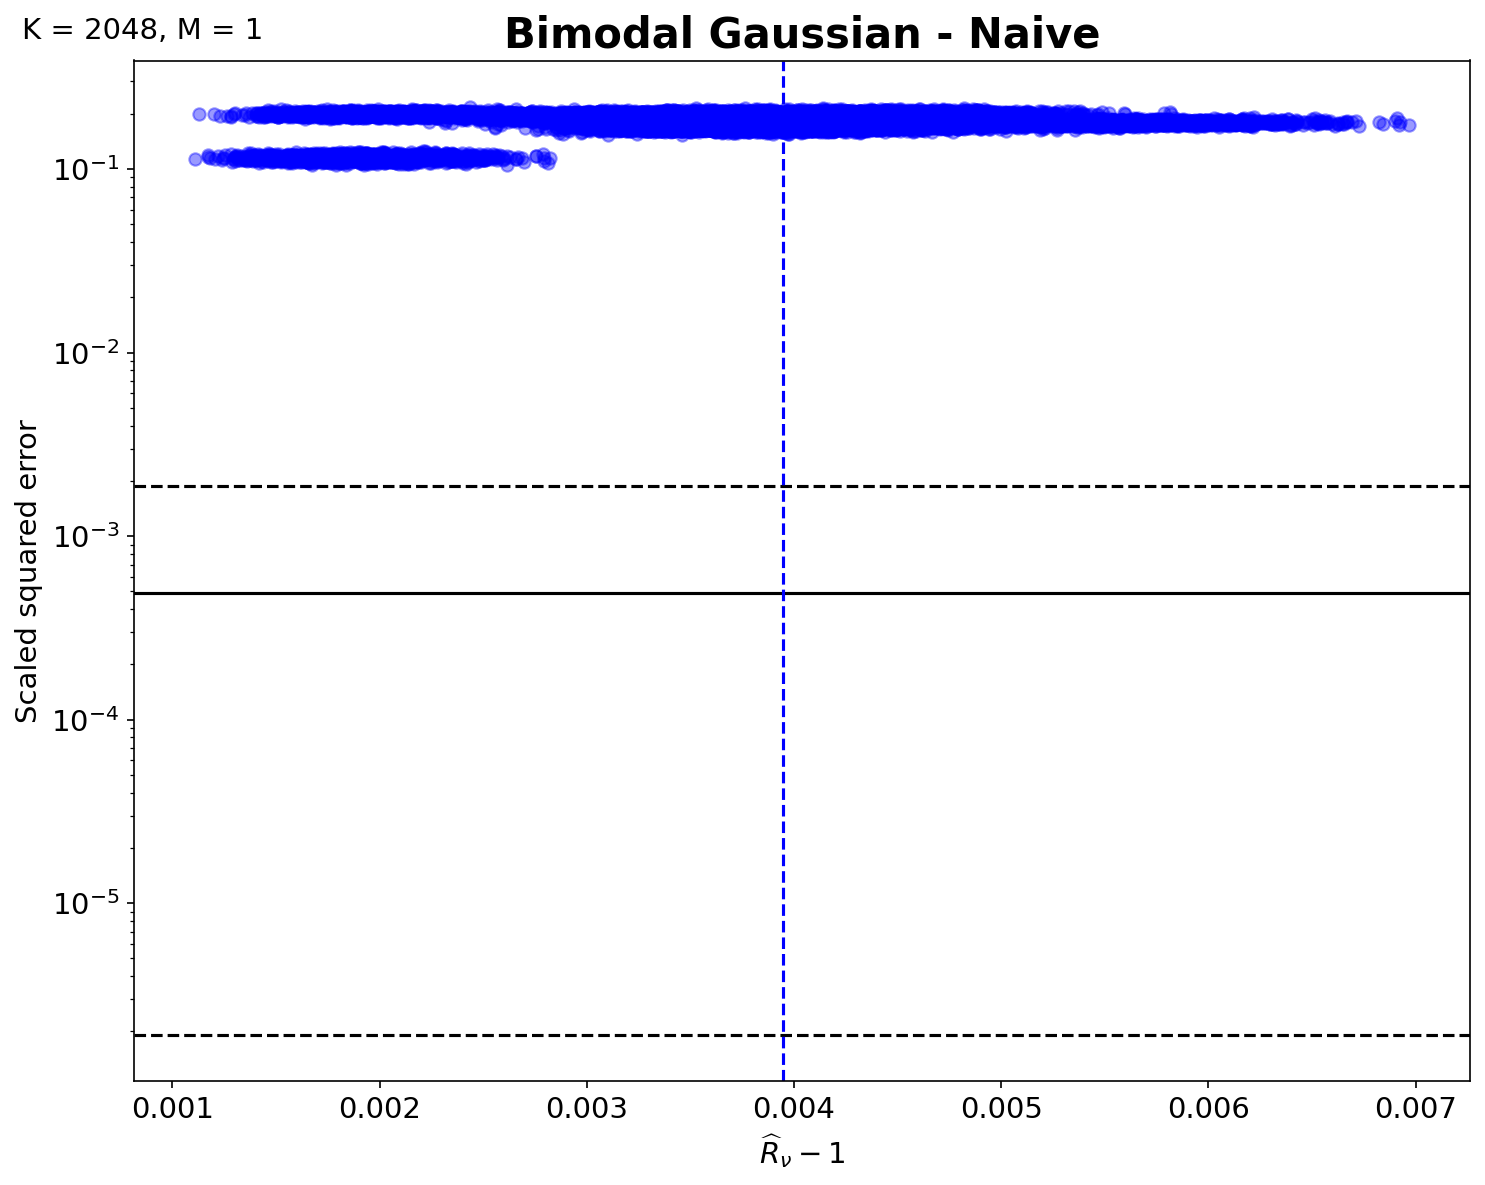

In [17]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Bimodal Gaussian", True,
            bound, threshold,num_chains_short, num_chains_short)

*Enhanced Plots: multiple line plots*

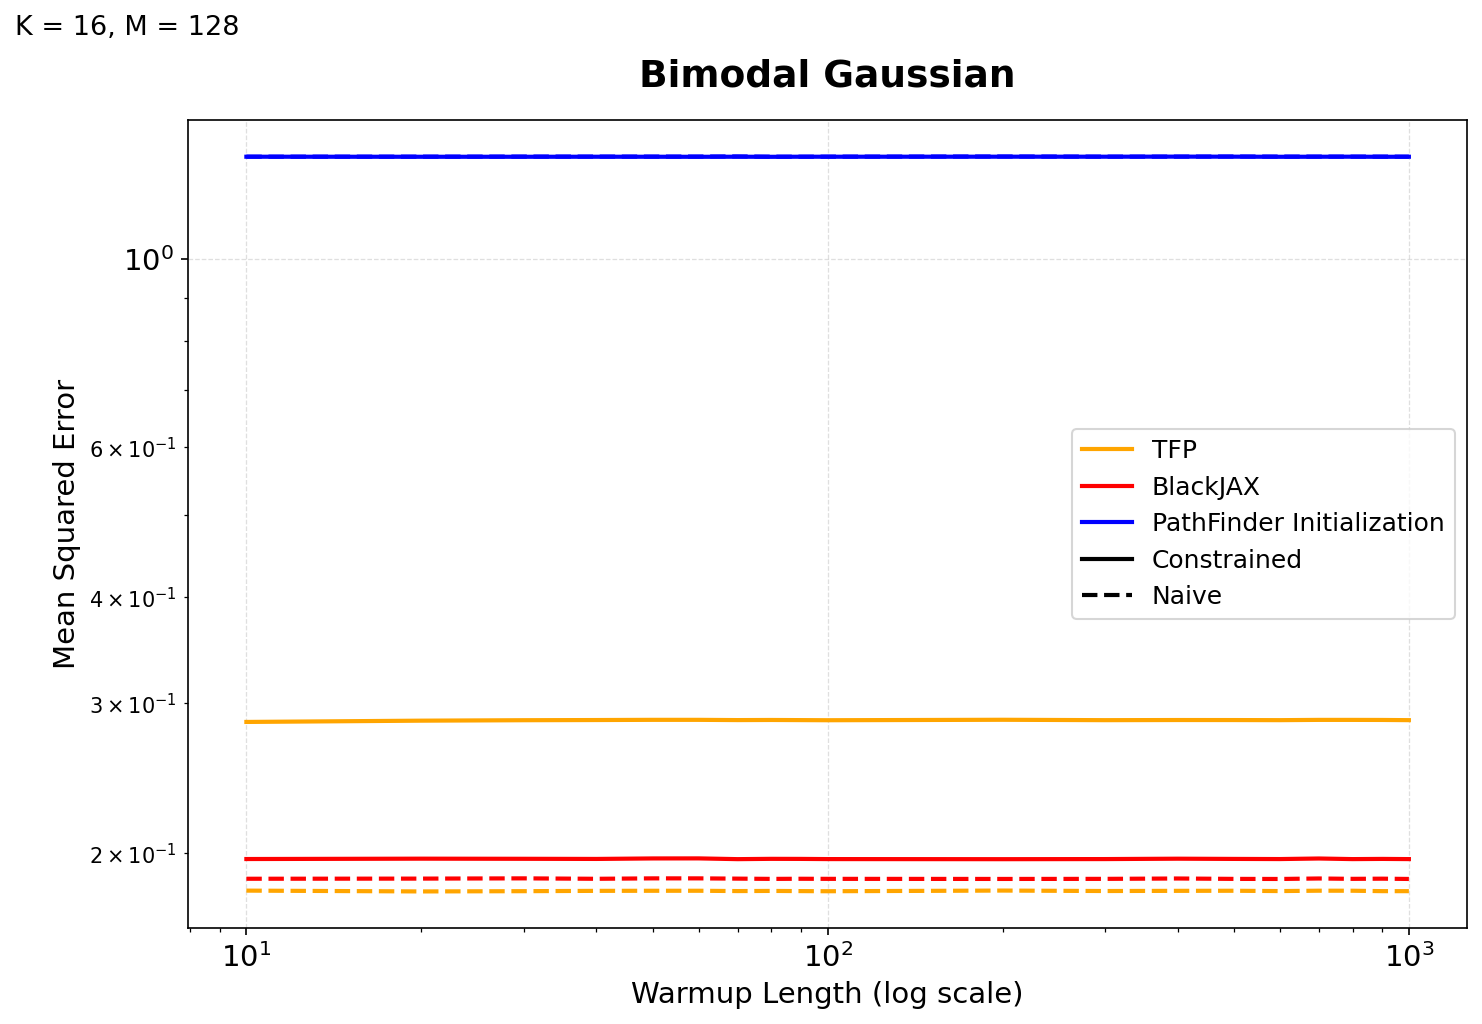

In [18]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_c_df, pf_MSE_n_df,
                    "Bimodal Gaussian", num_super_chains, M)

*Enhanced Plots: colored Scatter Plots*

In [19]:
dfs=[tfp_R_Hat_c_df, bjx_R_Hat_c_df, pf_R_Hat_c_df,
     tfp_R_Hat_n_df, bjx_R_Hat_n_df, pf_R_Hat_n_df]

titles =["TFP - Constrained","BlackJAX - Constrained","PathFinder - Constrained",
         "TFP - Naive","BlackJAX - Naive","PathFinder - Naive"]

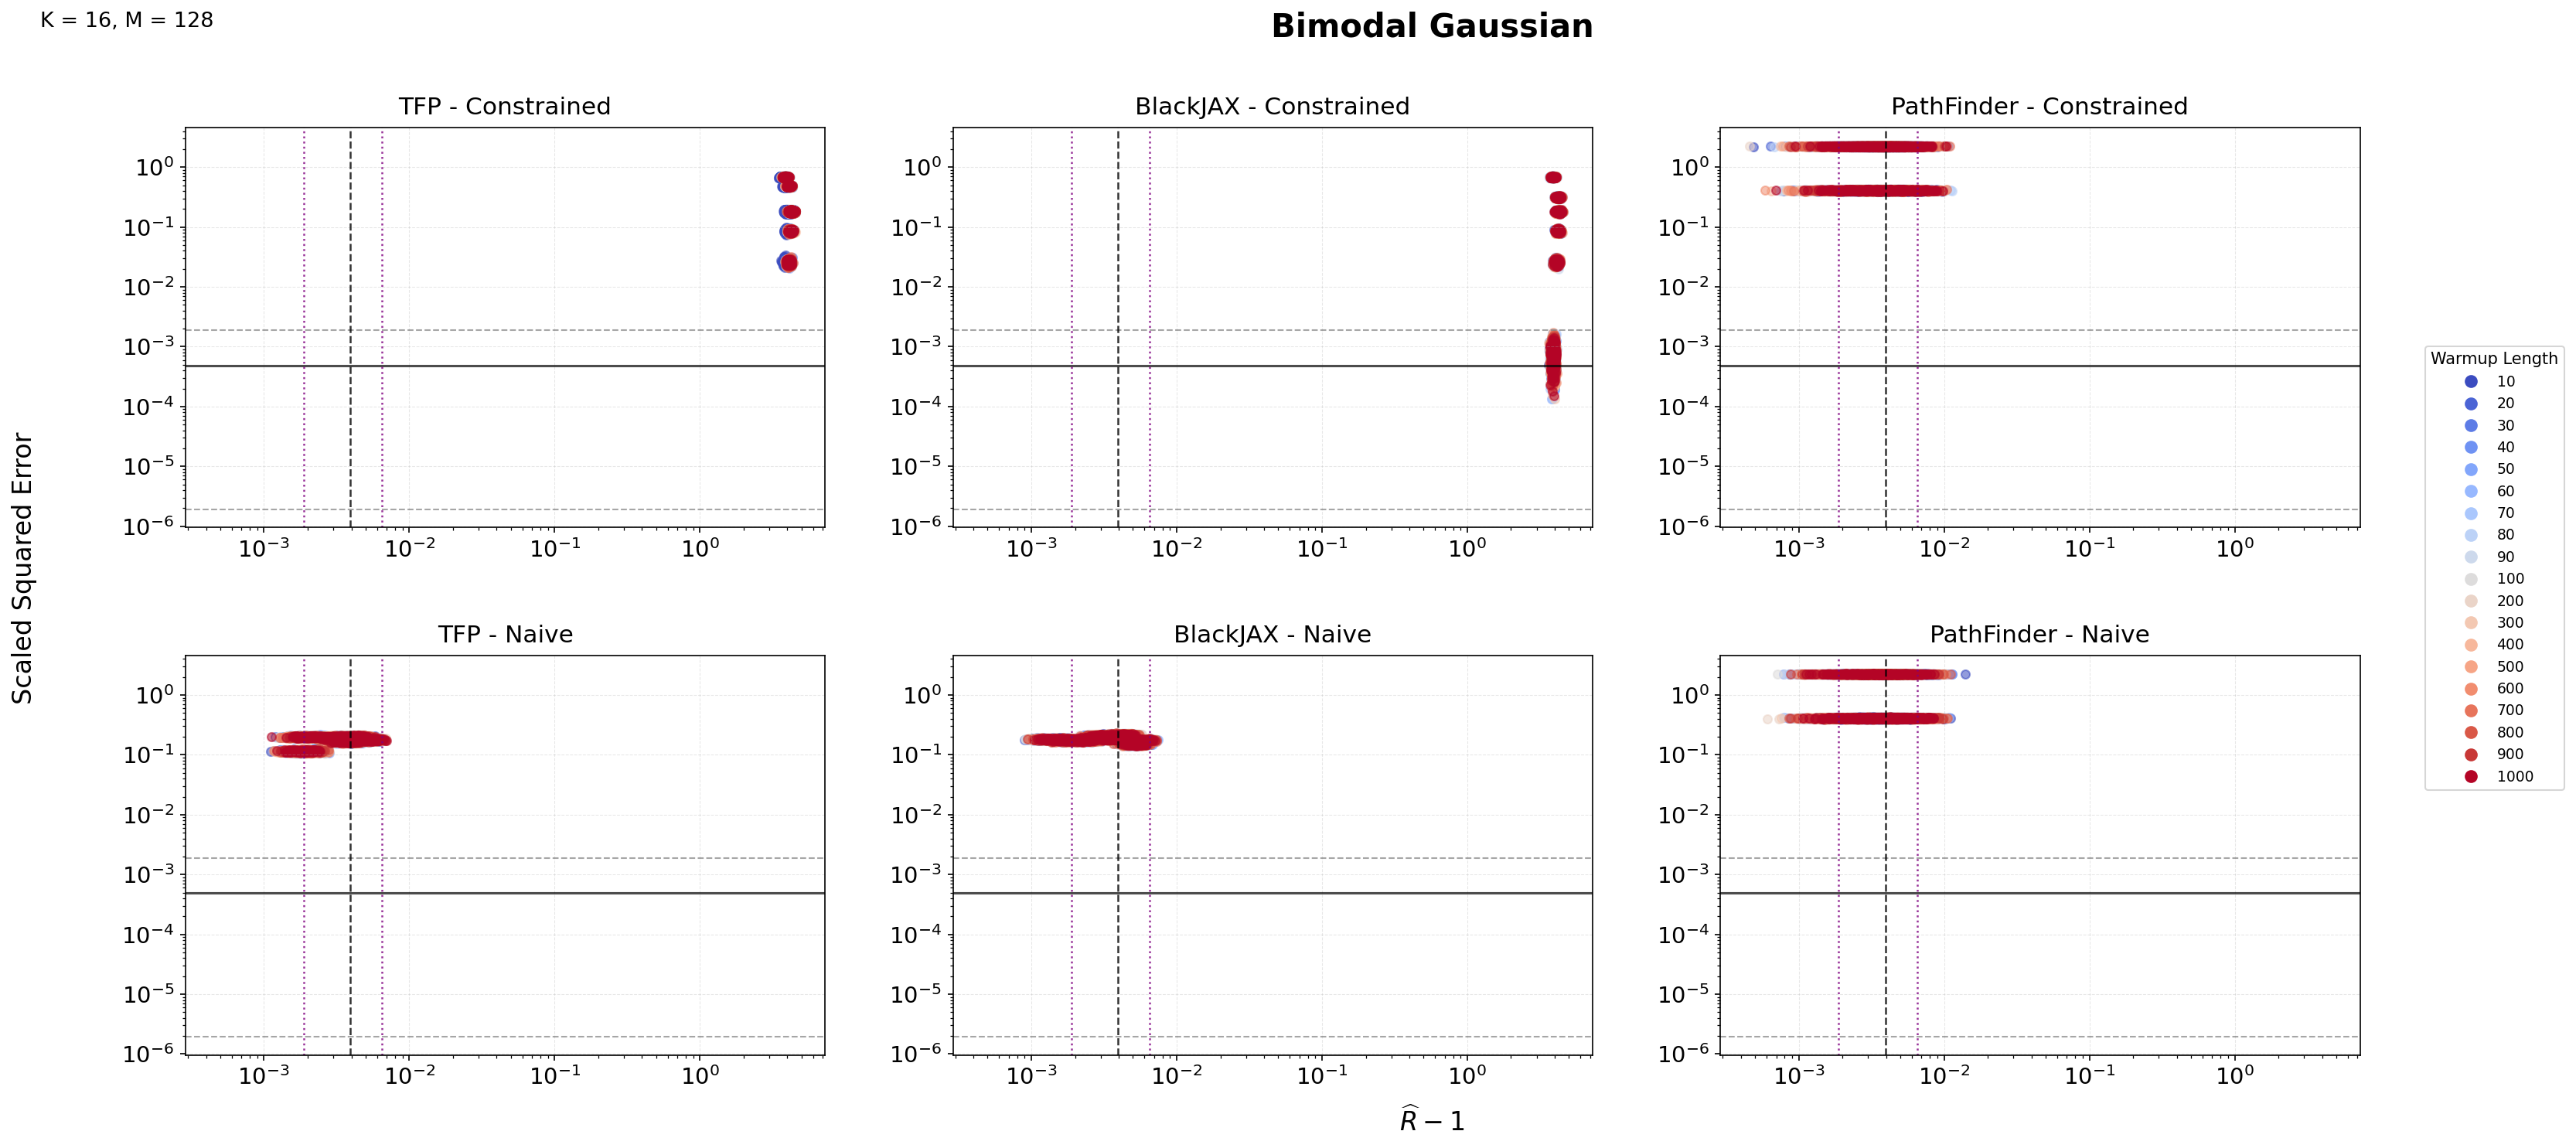

In [20]:
MSE_vs_Rhat_color(dfs, titles,"Bimodal Gaussian",bound, threshold,
                  num_chains_short, num_super_chains)

**Eight Schools Example**

In [21]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/School_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# New PF initialization:
# MSE vs Warmups:
pf_MSE_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/School_MSE.pkl"
pf_MSE_c_df = pd.read_pickle(pf_MSE_c_path)
# MSE vs nested Rhat:
pf_R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/School_R_Hat.pkl"
pf_R_Hat_c_df = pd.read_pickle(pf_R_Hat_c_path)

# MSE vs Warmups:
pf_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_MSE.pkl"
pf_MSE_n_df = pd.read_pickle(pf_MSE_n_path)
# MSE vs nested Rhat:
pf_R_Hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_R_Hat.pkl"
pf_R_Hat_n_df = pd.read_pickle(pf_R_Hat_n_path)
print("PathFinder implementation data Loaded!")

TFP implementation data Loaded!
BlackJAX implementation data Loaded!
PathFinder implementation data Loaded!


*Original Paper: line plot*

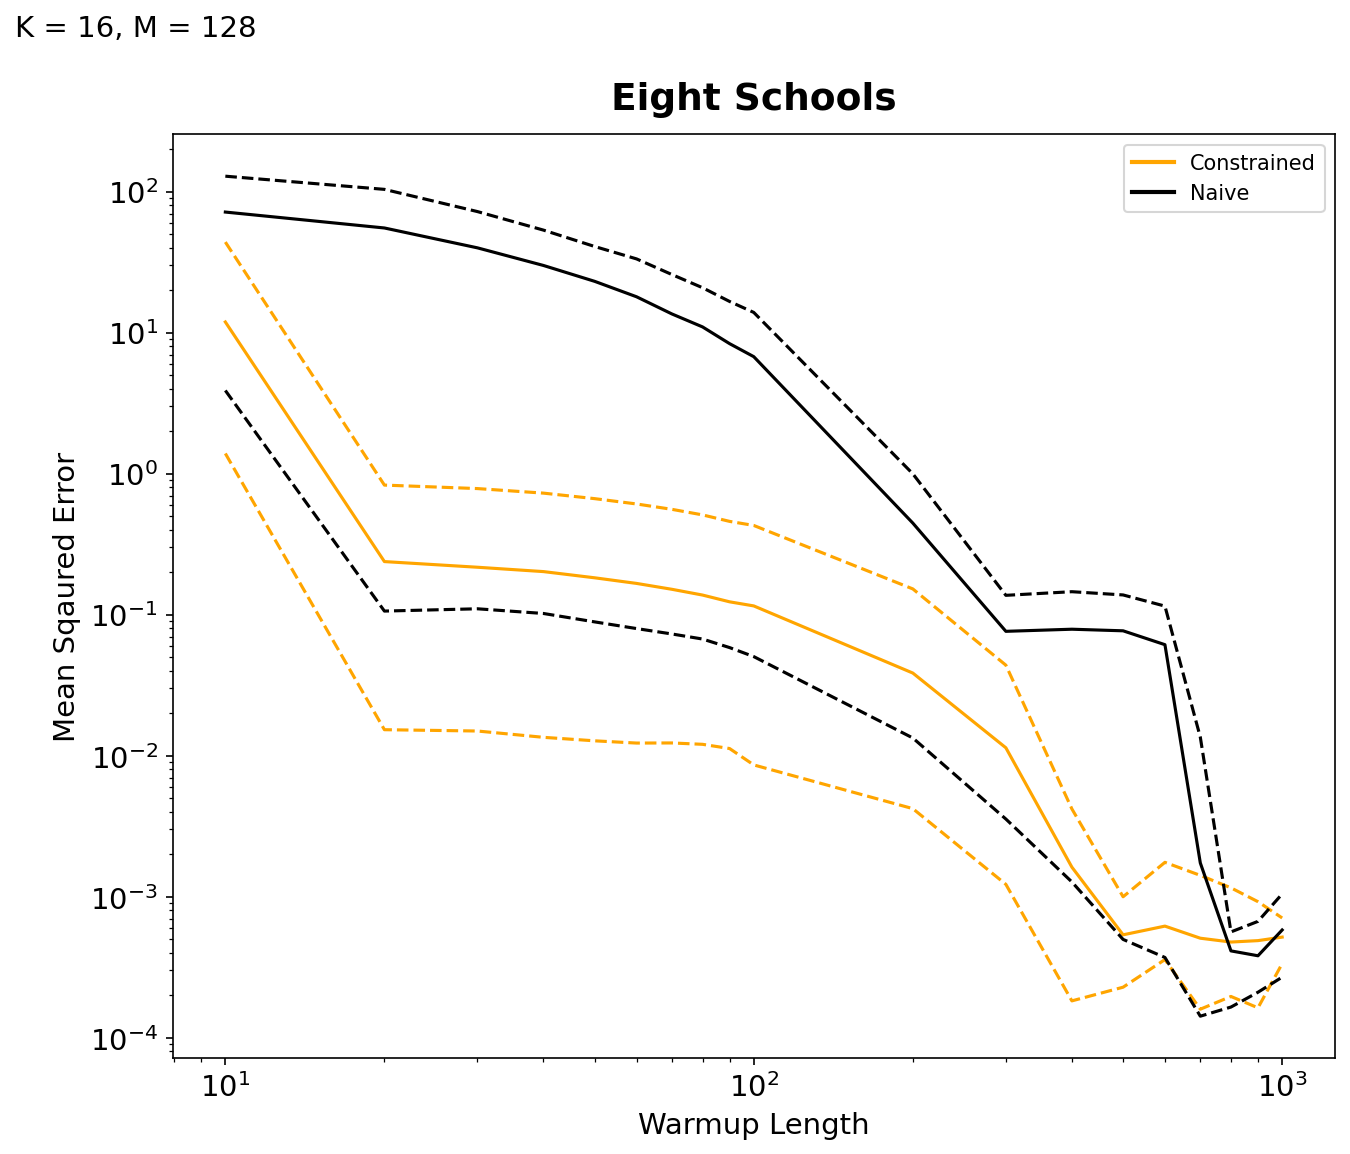

In [23]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Eight Schools", num_super_chains, M)

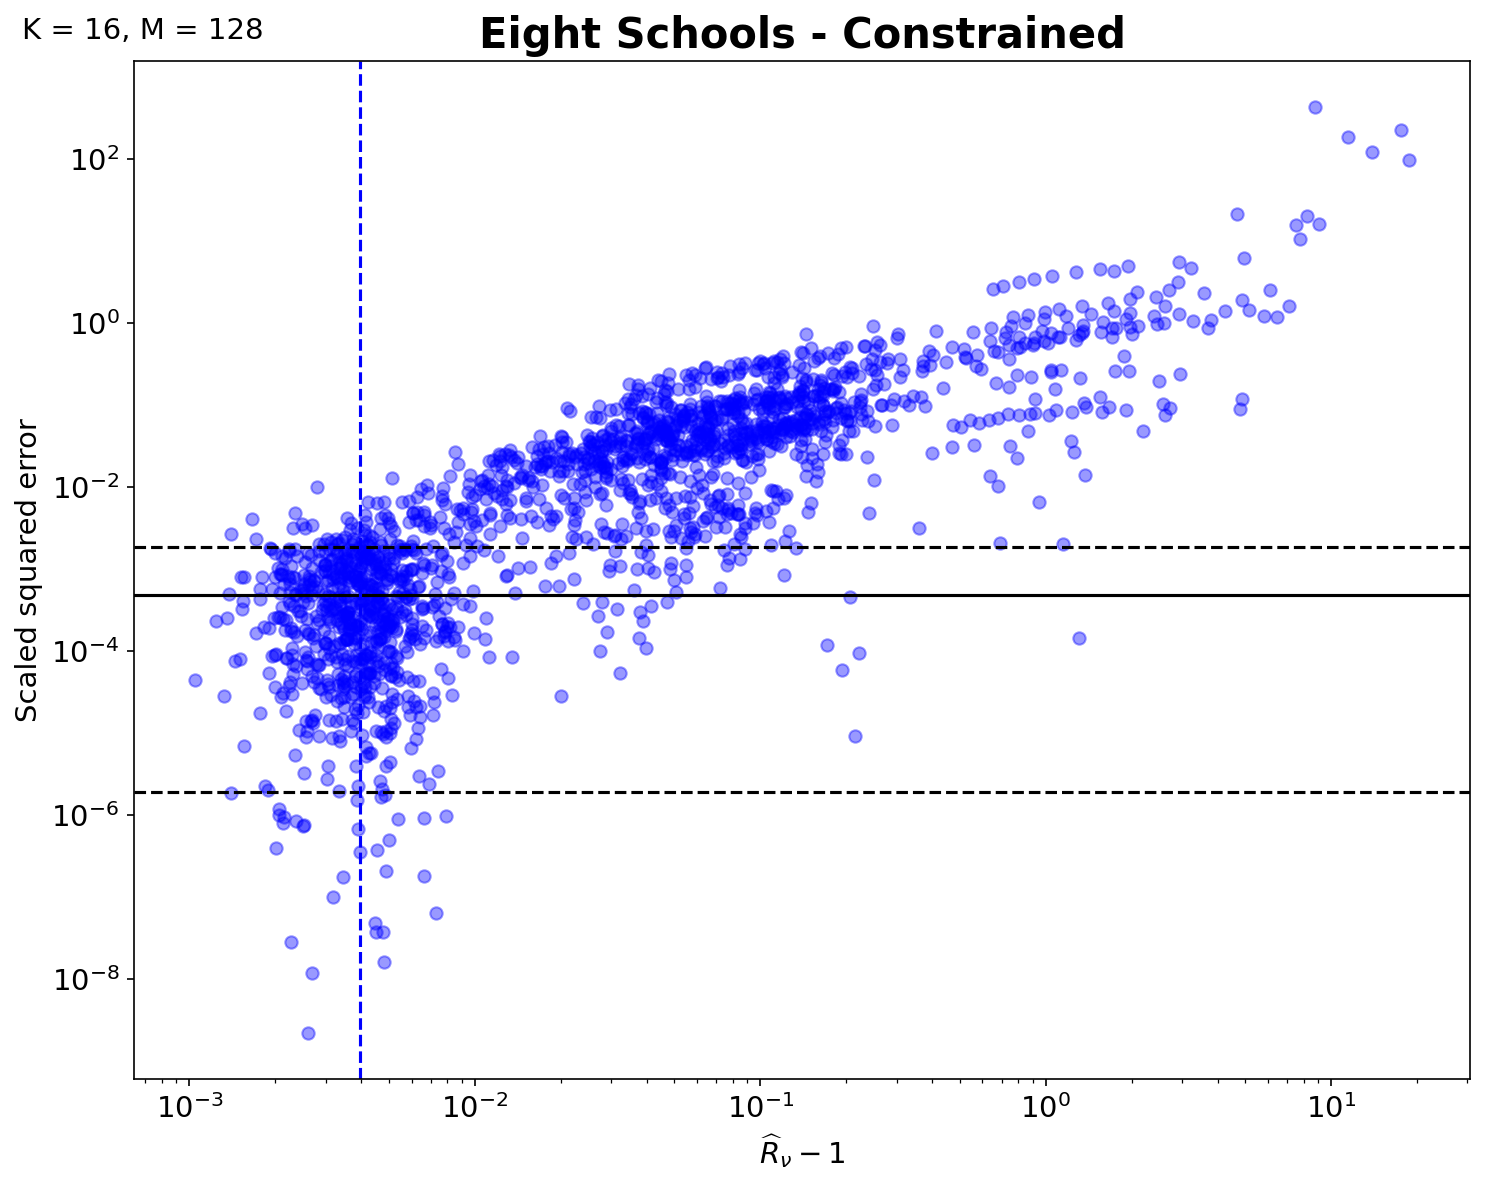

In [24]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Eight Schools", False,
            bound, threshold,num_super_chains,num_chains_short)

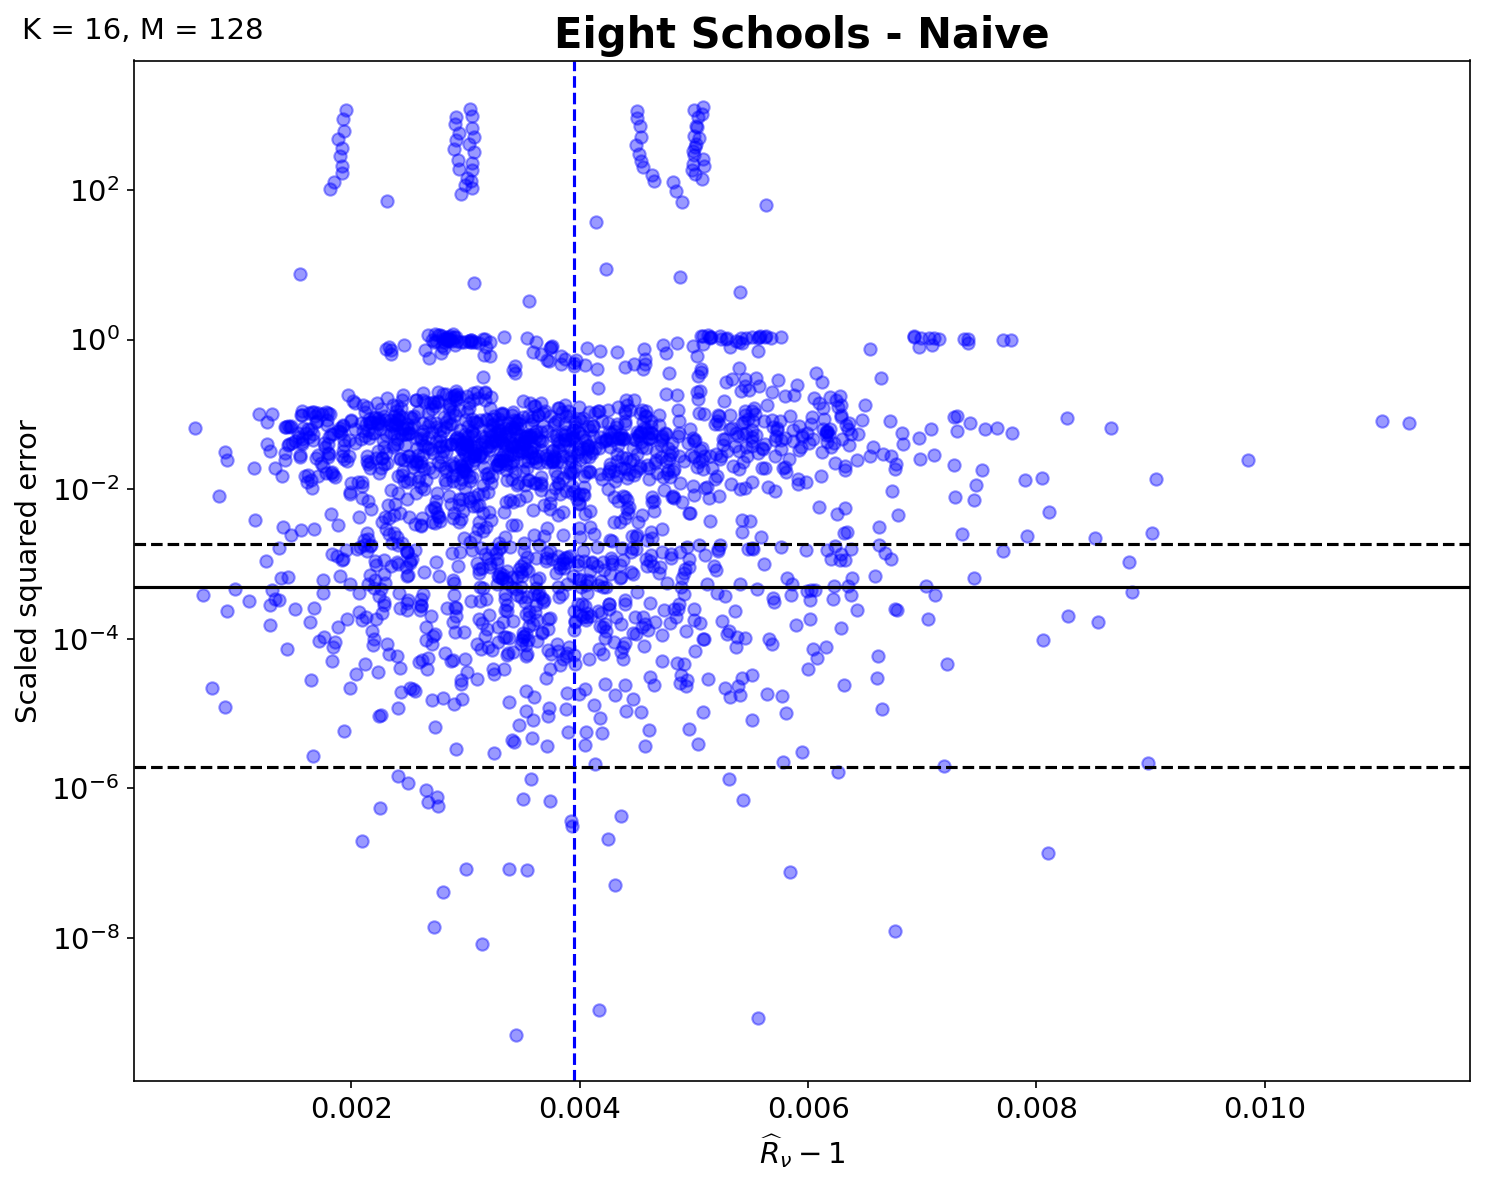

In [25]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Eight Schools", True,
            bound, threshold, num_super_chains, num_chains_short)

*Enhanced Plots: multiple line plots*

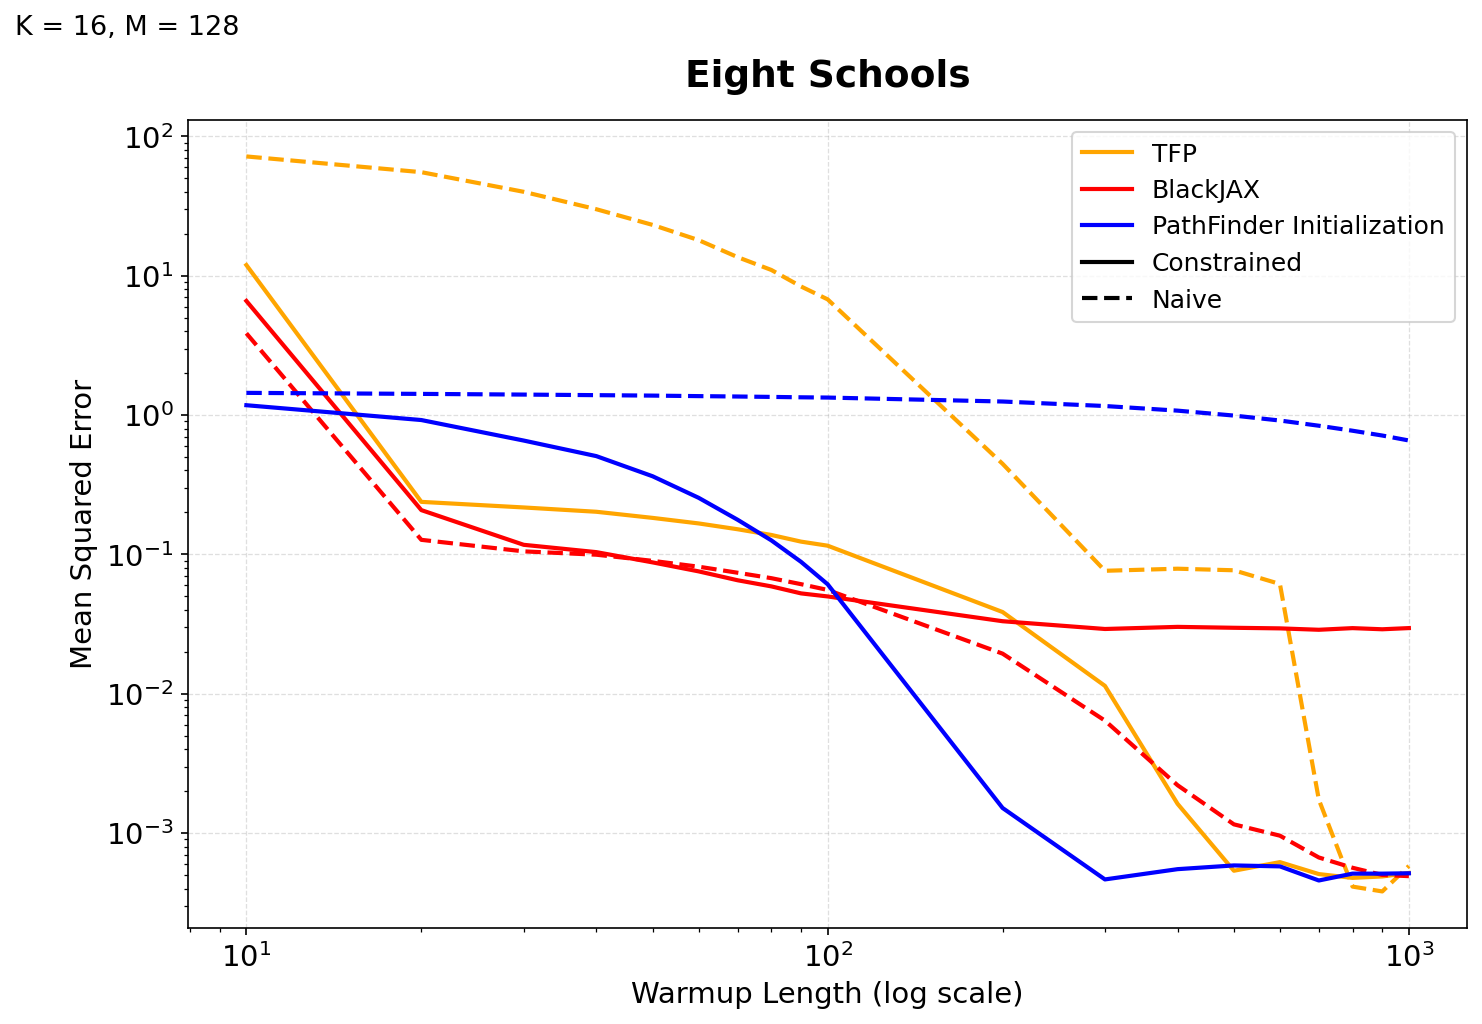

In [26]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_c_df, pf_MSE_n_df,
                    "Eight Schools", num_super_chains, M)

*Enhanced Plots: colored Scatter Plots*

In [27]:
dfs=[tfp_R_Hat_c_df, bjx_R_Hat_c_df, pf_R_Hat_c_df,
     tfp_R_Hat_n_df, bjx_R_Hat_n_df, pf_R_Hat_n_df]

titles =["TFP - Constrained","BlackJAX - Constrained","PathFinder - Constrained",
         "TFP - Naive","BlackJAX - Naive","PathFinder - Naive"]

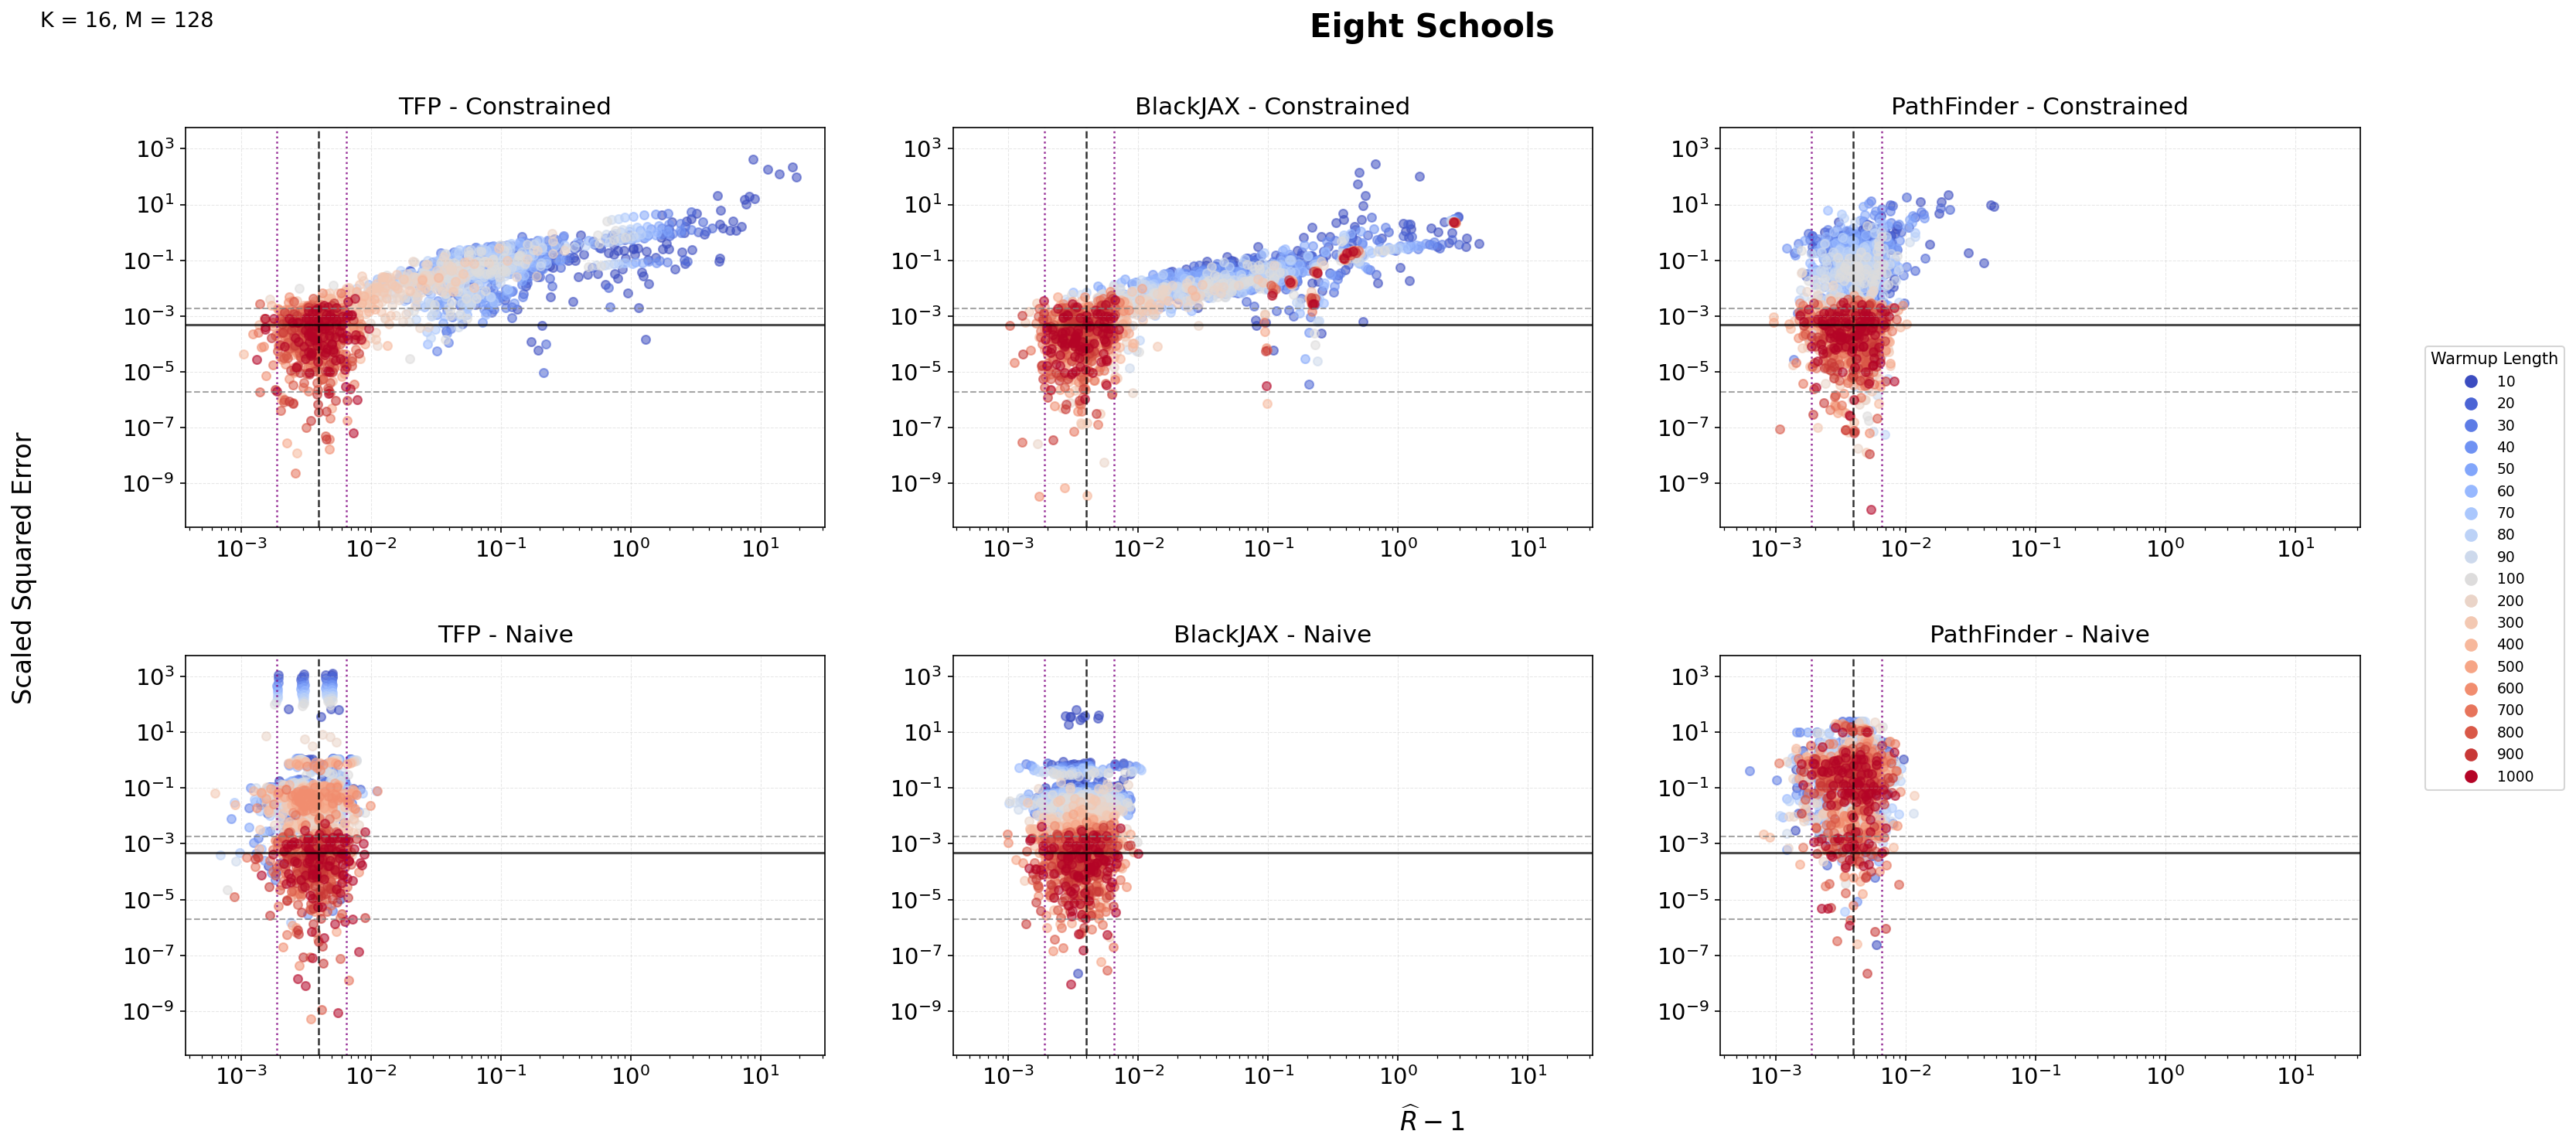

In [29]:
MSE_vs_Rhat_color(dfs, titles, "Eight Schools",bound,
                  threshold,num_chains_short,num_super_chains)

**Item Response Theory Example**

In [30]:
##########################
# TFP implementation:
##########################
# MSE vs Warmups:
tfp_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_constrained.pkl"
tfp_MSE_c_df = pd.read_pickle(tfp_MSE_c_path)

tfp_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_MSE_naive.pkl"
tfp_MSE_n_df = pd.read_pickle(tfp_MSE_n_path)
# MSE vs nested Rhat:
tfp_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_constrained.pkl"
tfp_R_Hat_c_df = pd.read_pickle(tfp_R_hat_c_path)

tfp_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/pkl_files/IRT_R_Hat_naive.pkl"
tfp_R_Hat_n_df = pd.read_pickle(tfp_R_hat_n_path)
print("TFP implementation data Loaded!")
##########################
# BlackJAX implementation:
##########################
# MSE vs Warmups:
bjx_MSE_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_MSE_constrained.pkl"
bjx_MSE_c_df = pd.read_pickle(bjx_MSE_c_path)

bjx_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_MSE_naive.pkl"
bjx_MSE_n_df = pd.read_pickle(bjx_MSE_n_path)
# MSE vs nested Rhat:
bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_constrained.pkl"
bjx_R_Hat_c_df = pd.read_pickle(bjx_R_hat_c_path)

bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_naive.pkl"
bjx_R_Hat_n_df = pd.read_pickle(bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")
##########################
# BlackJAX implementation, with PathFinder Initialization:
##########################
# New PF initialization:
# MSE vs Warmups:
pf_MSE_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/IRT_MSE.pkl"
pf_MSE_c_df = pd.read_pickle(pf_MSE_c_path)
# MSE vs nested Rhat:
pf_R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/IRT_R_Hat.pkl"
pf_R_Hat_c_df = pd.read_pickle(pf_R_Hat_c_path)

# MSE vs Warmups:
pf_MSE_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/IRT_MSE.pkl"
pf_MSE_n_df = pd.read_pickle(pf_MSE_n_path)
# MSE vs nested Rhat:
pf_R_Hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/IRT_R_Hat.pkl"
pf_R_Hat_n_df = pd.read_pickle(pf_R_Hat_n_path)
print("PathFinder implementation data Loaded!")

TFP implementation data Loaded!
BlackJAX implementation data Loaded!
PathFinder implementation data Loaded!


*Original Paper: line plot*

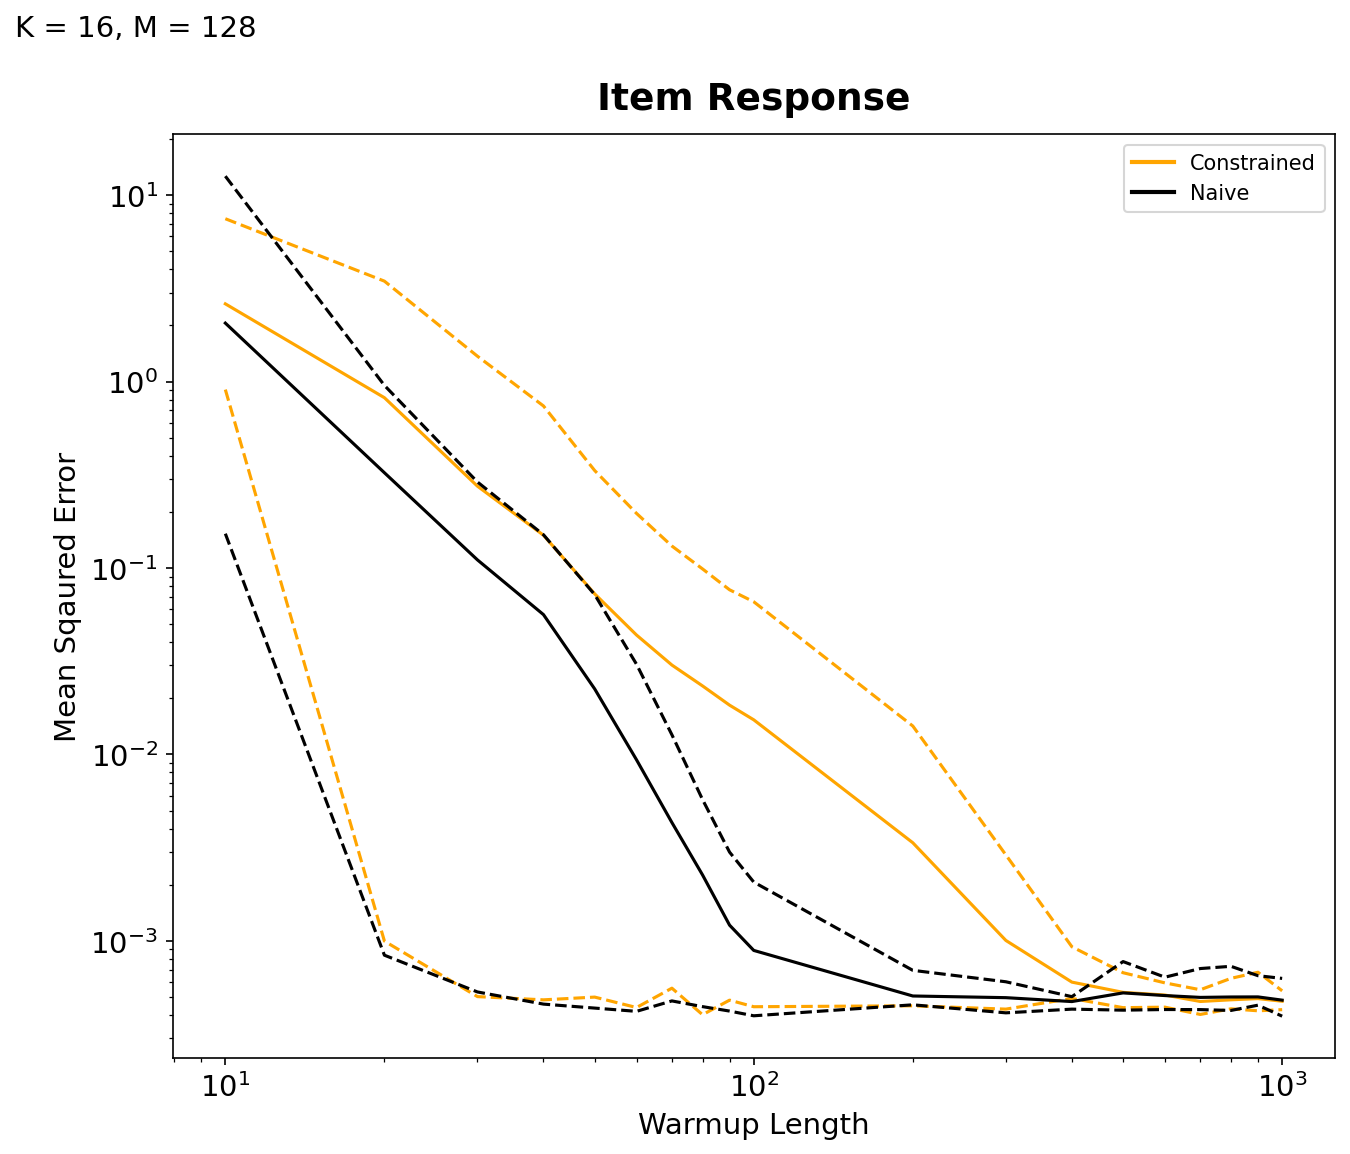

In [31]:
MSE_vs_Warmup(tfp_MSE_c_df, tfp_MSE_n_df, "Item Response", num_super_chains, M)

*Original Paper: Scatter plot*

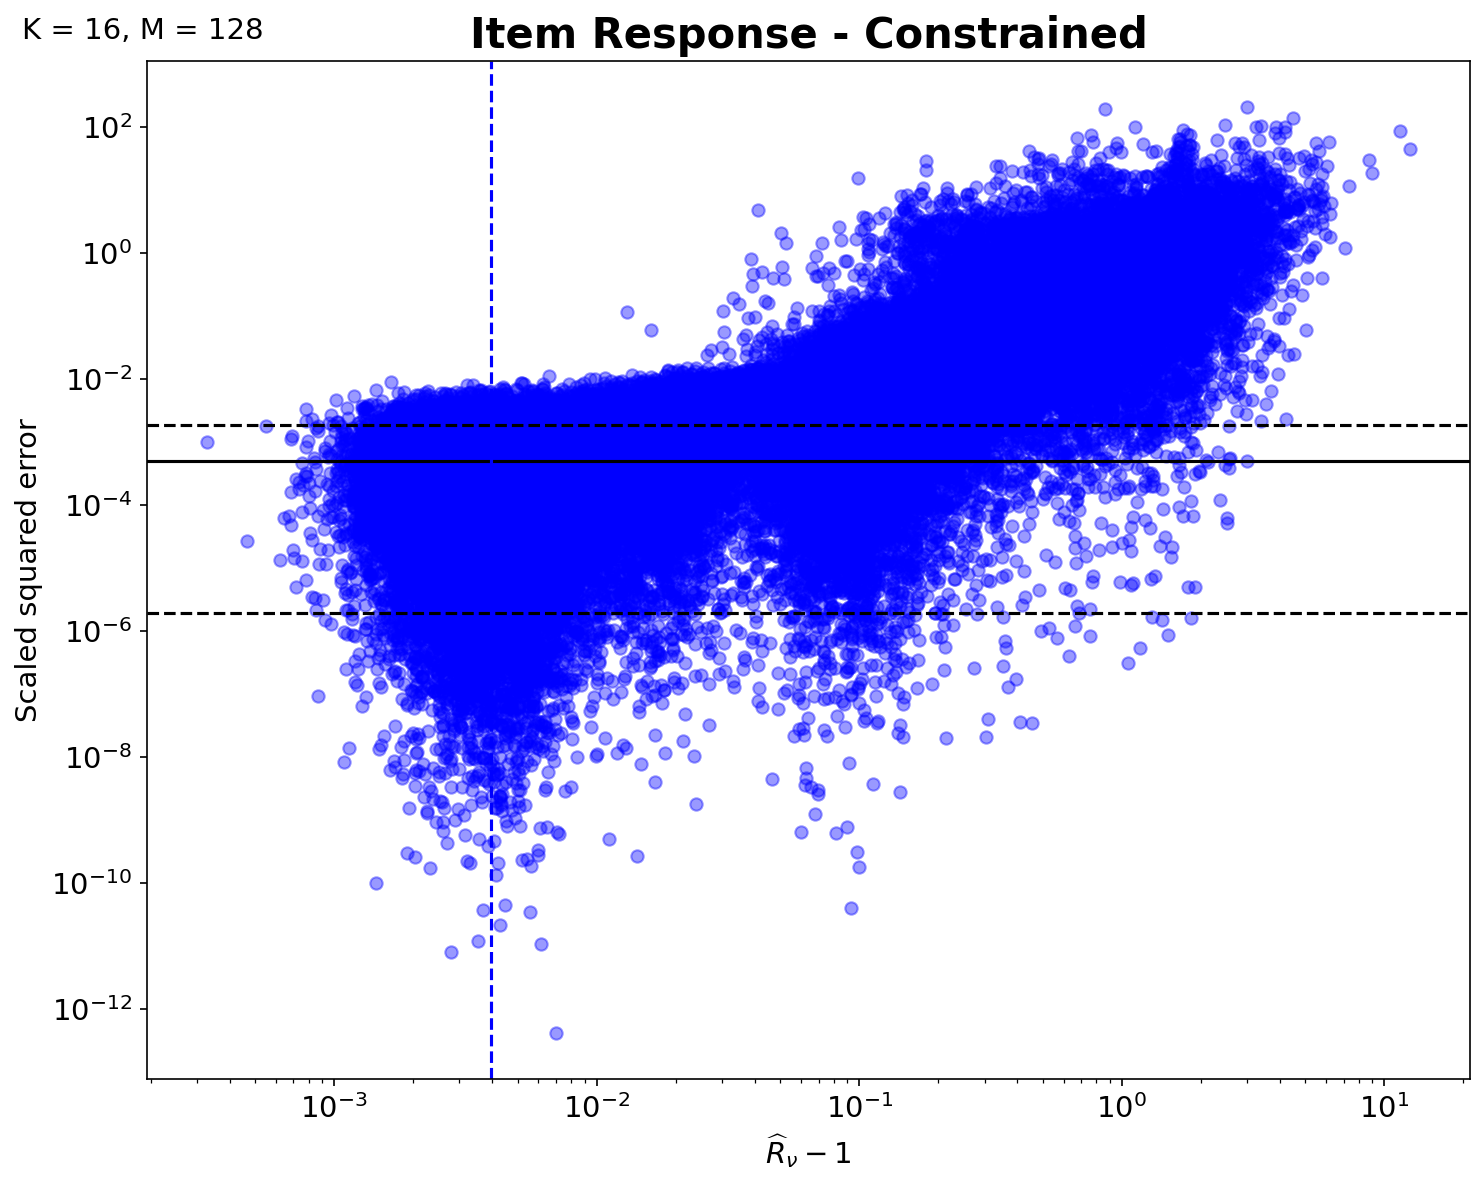

In [32]:
MSE_vs_Rhat(tfp_R_Hat_c_df, "Item Response", False,
            bound, threshold,num_super_chains, num_chains_short)

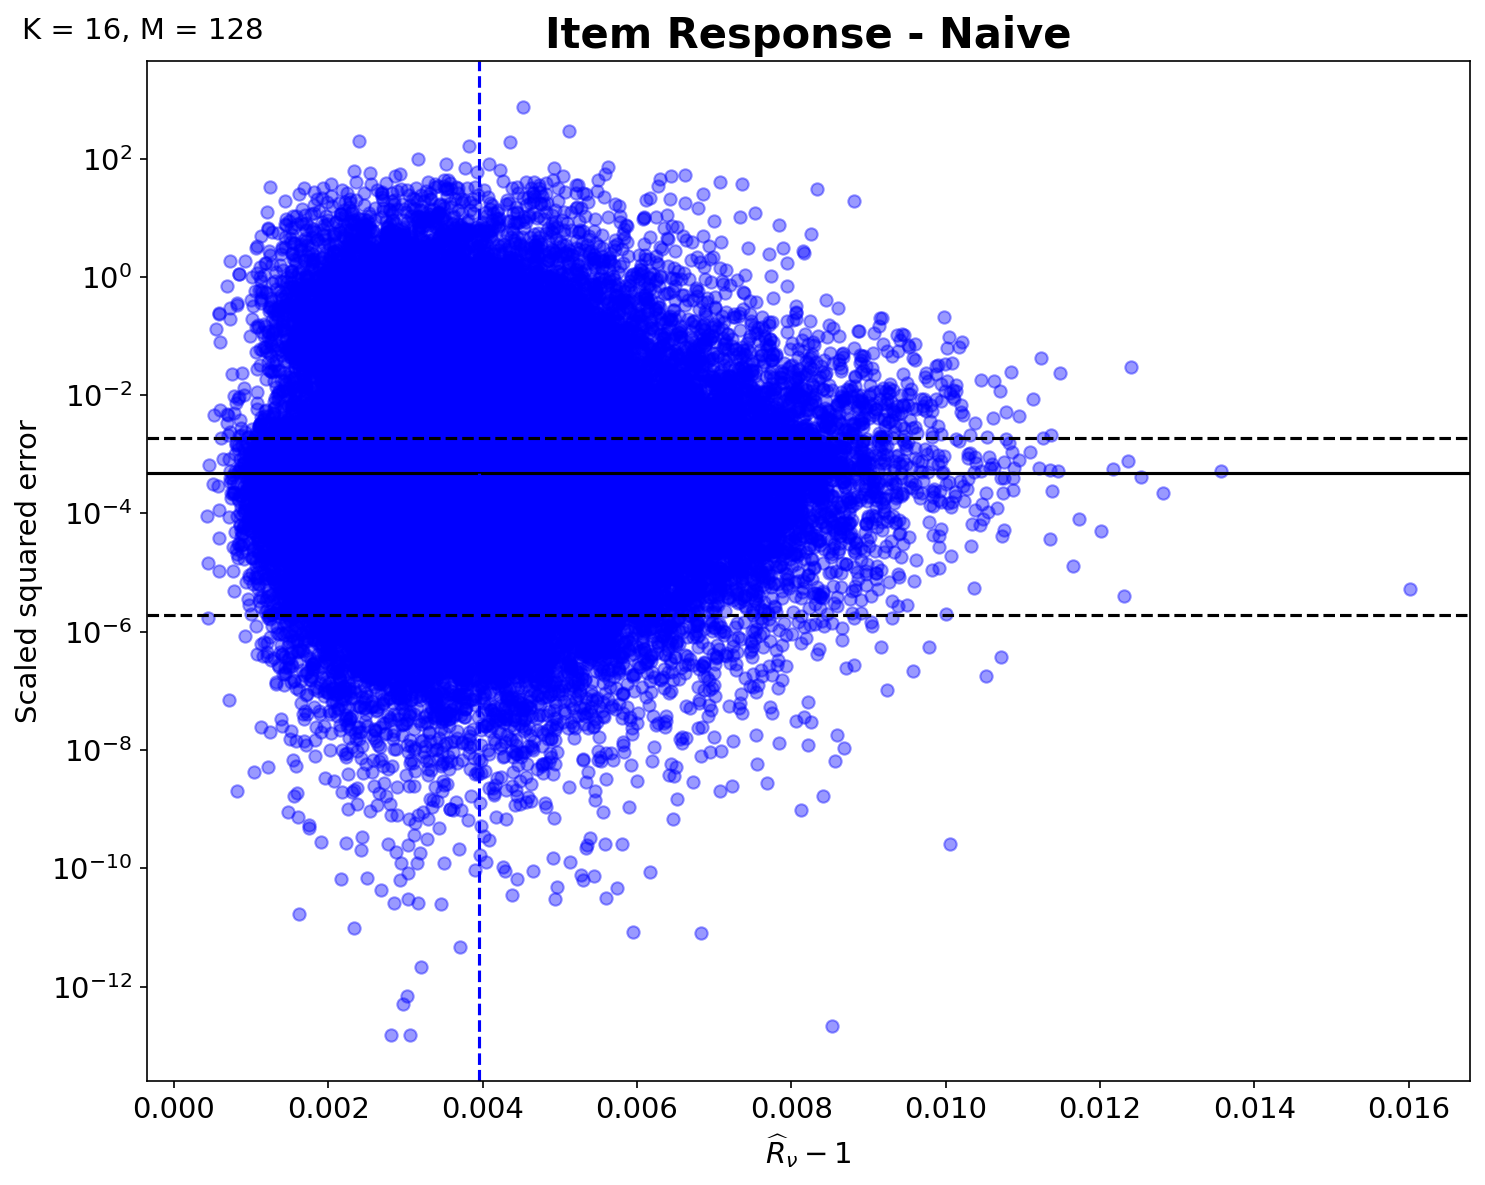

In [33]:
MSE_vs_Rhat(tfp_R_Hat_n_df, "Item Response", True,
            bound, threshold,num_super_chains, num_chains_short)

*Enhanced Plots: multiple line plots*

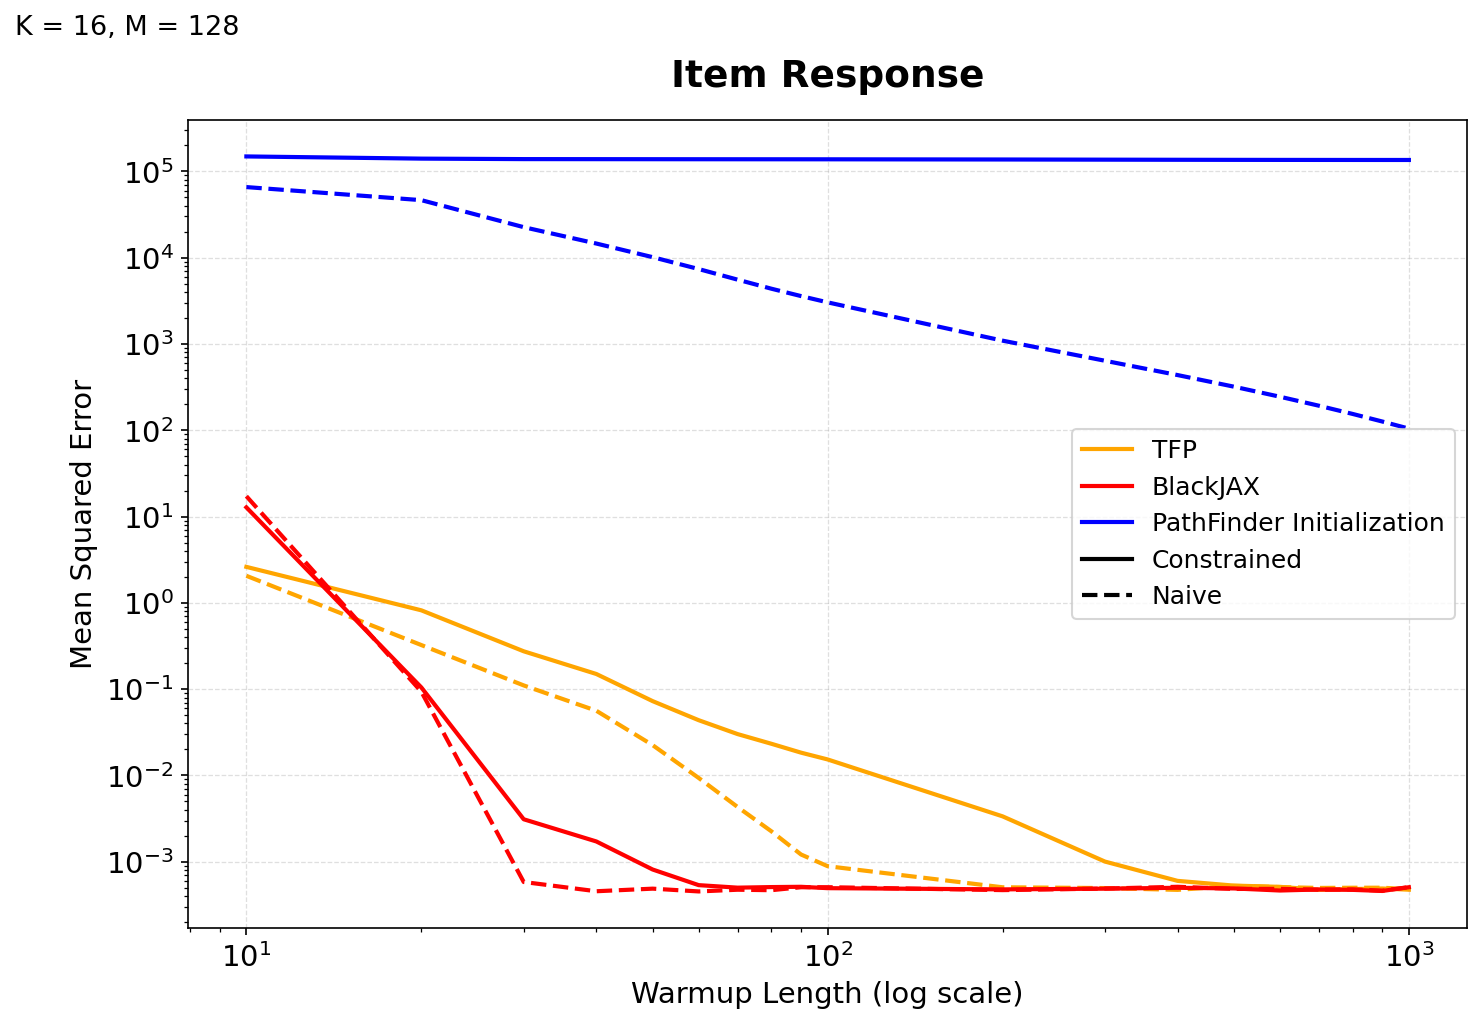

In [34]:
MSE_vs_Warmup_Jumbo(tfp_MSE_c_df, tfp_MSE_n_df,
                    bjx_MSE_c_df, bjx_MSE_n_df,
                    pf_MSE_c_df, pf_MSE_n_df,
                    "Item Response", num_super_chains, M)

*Enhanced Plots: colored Scatter Plots*

In [35]:
dfs=[tfp_R_Hat_c_df, bjx_R_Hat_c_df, pf_R_Hat_c_df,
     tfp_R_Hat_n_df, bjx_R_Hat_n_df, pf_R_Hat_n_df]

titles =["TFP - Constrained","BlackJAX - Constrained","PathFinder - Constrained",
         "TFP - Naive","BlackJAX - Naive","PathFinder - Naive"]

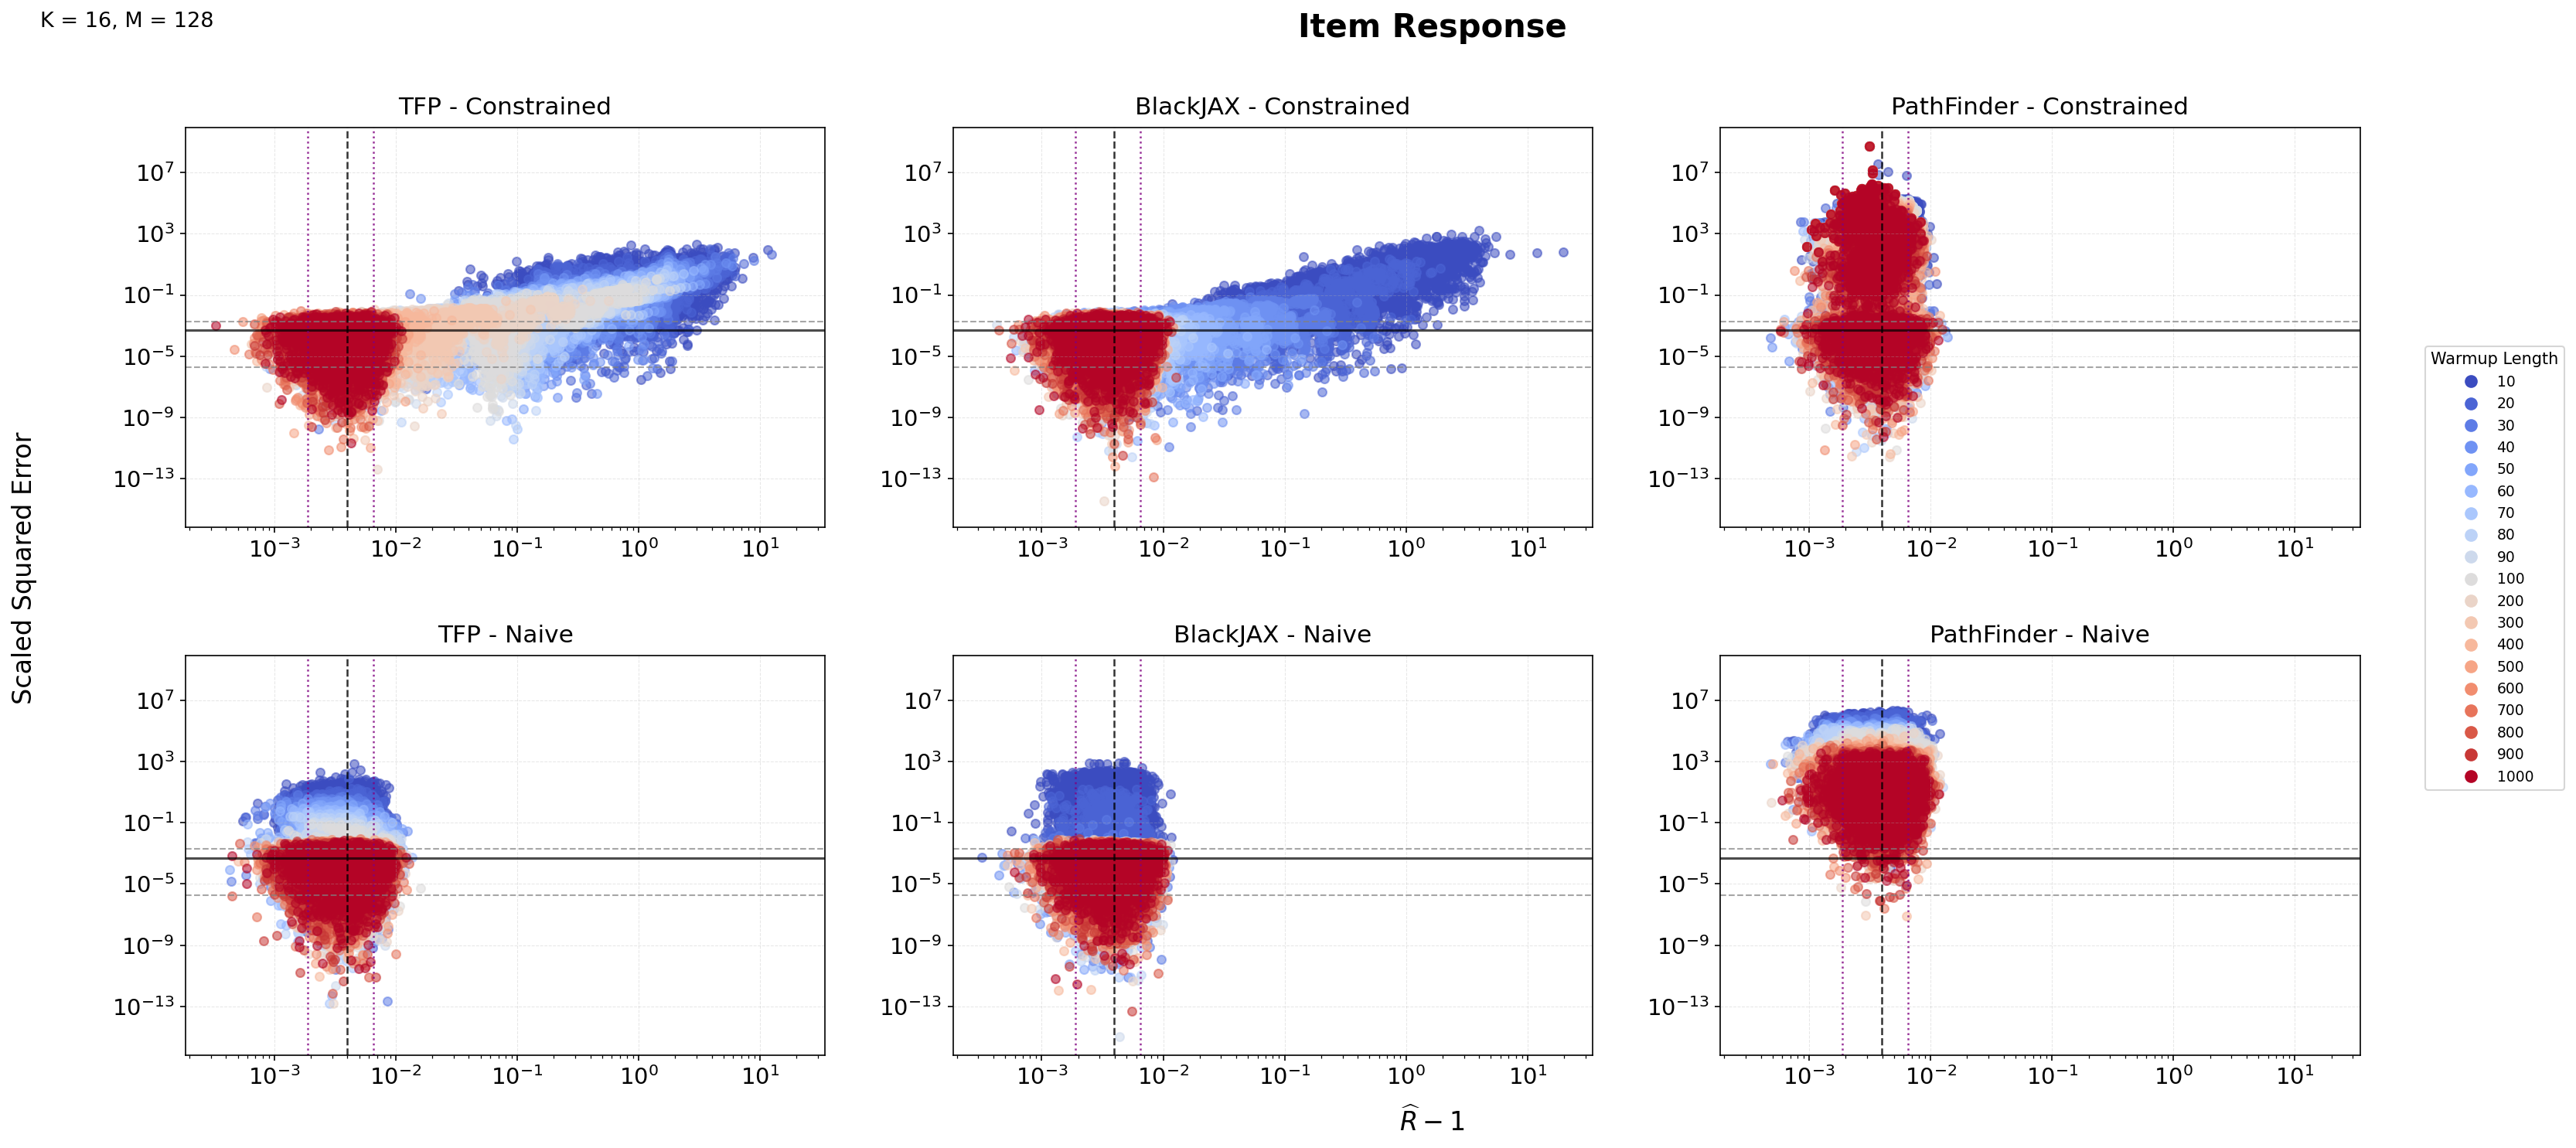

In [36]:
MSE_vs_Rhat_color(dfs, titles,"Item Response",bound,
                  threshold,num_chains_short, num_super_chains)